In [ ]:
import numpy as np
from astropy.io import fits
import stpsf
from astropy.nddata import Cutout2D
from tqdm import tqdm
import astropy.wcs.utils as utils
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import matplotlib

In [2]:
path_image1 = "/home/wesley/Desktop/JWST_REU/2025_stage_2_data/"
fits_file = '/home/wesley/Desktop/JWST_REU/2025_stage_2_data/nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'

In [3]:
hdul = fits.open((path_image1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))
hdu_c_psf = fits.open('/home/wesley/Desktop/JWST_REU/coarse_psf_stack.fits')
hdu_f_psf = fits.open('/home/wesley/Desktop/JWST_REU/fine_psf_stack.fits')

In [4]:
x_coords = [41, 88, 315, 471, 433, 785, 673, 1162, 178, 1312, 1689, 1778, 1965, 2002]
y_coords = [431, 421, 404, 405, 97, 144, 779, 874, 1910, 1752, 1090, 967, 1055, 481]

In [5]:
image = hdul[1].data
header = hdul[1].header

In [6]:
def psf_fitting(x_coords, y_coords, psf_library):
    x_coords = np.round(x_coords)
    y_coords = np.round(y_coords)

    psf_center = (x_coords, y_coords)
    boxsize = 50

    obs_psf = Cutout2D(hdul['SCI'].data, position=psf_center, size=boxsize, mode='partial', fill_value=np.nan).data.copy()
    obs_psf_err = Cutout2D(hdul['ERR'].data, position=psf_center, size=boxsize, mode='partial', fill_value=np.nan).data.copy()

    obs_psf -= np.nanmedian(obs_psf)          

    valid   = np.isfinite(obs_psf) & np.isfinite(obs_psf_err) & (obs_psf_err > 0)
    n_valid = int(valid.sum())
    err_sq  = obs_psf_err[valid] ** 2     

    chi_squared = []

    x_shifts = []
    y_shifts = []

    for k in range(len(psf_library) - 1):
        x_shifts.append(psf_library[k+1].header['XSHIFT'])
        y_shifts.append(psf_library[k+1].header['ySHIFT'])

        sim_psf = psf_library[k+1].data

        scalefactor = np.nansum(obs_psf) / np.nansum(sim_psf)


        diff = (obs_psf - (sim_psf * scalefactor))[valid]        

        chi_squared.append(np.nansum(diff**2/err_sq)/np.isfinite(diff).sum())
    
    min_value = np.argmin(chi_squared)
    min_chi = chi_squared[min_value]
    best_x = x_shifts[min_value]
    best_y = y_shifts[min_value]



    x_axis_scale = np.sqrt(header['CD1_1'] **2 + header['CD2_1'] **2 ) * 3600
    y_axis_scale = np.sqrt(header['CD1_2'] **2 + header['CD2_2'] **2 ) * 3600


    x_pixel_shift = best_x / x_axis_scale
    y_pixel_shift = best_y / y_axis_scale

    new_x = x_coords + x_pixel_shift
    new_y = y_coords + y_pixel_shift


    print (new_x, new_y)


    chi_squared = np.array(chi_squared)

    n_grid = int(np.sqrt(len(psf_library) - 1))

    chi_squ_2d = np.array((chi_squared/ np.min(chi_squared))).reshape(n_grid, n_grid)


    x_grid_2d = np.array(x_shifts).reshape(n_grid, n_grid)
    y_grid_2d = np.array(y_shifts).reshape(n_grid, n_grid)
    
    fig, ax = plt.subplots(figsize=(16, 9))

    levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ,13 ,14, 15, 16, 17,18, 19, 20]

    ct = ax.contour(x_grid_2d, y_grid_2d, chi_squ_2d, levels=levels, origin='lower')

    fig.colorbar(ct, ax=ax)
    ax.scatter(best_x,   best_y,   color='red',    s=50,  zorder=1000,
               label=f'Δx={best_x}"  Δy={best_y}"')
    
    ax.set_xlabel('X offset (arcsec)')
    ax.set_ylabel('Y offset (arcsec)')
    ax.legend()
    plt.rc('font', size=10)
    plt.tight_layout()
    plt.show()




    k_best = np.argmin(chi_squared)
    print(f"Best k: {k_best}")
    print(f"Best shift X: {psf_library[k_best+1].header['XSHIFT']}")
    print(f"Best shift Y: {psf_library[k_best+1].header['ySHIFT']}")
    print(f"fine_min_chi: {chi_squared[k_best]:.6f}")

 

    return (new_x, new_y, min_chi, best_x, best_y, min_value)

41.95569786953395 430.20747464099503


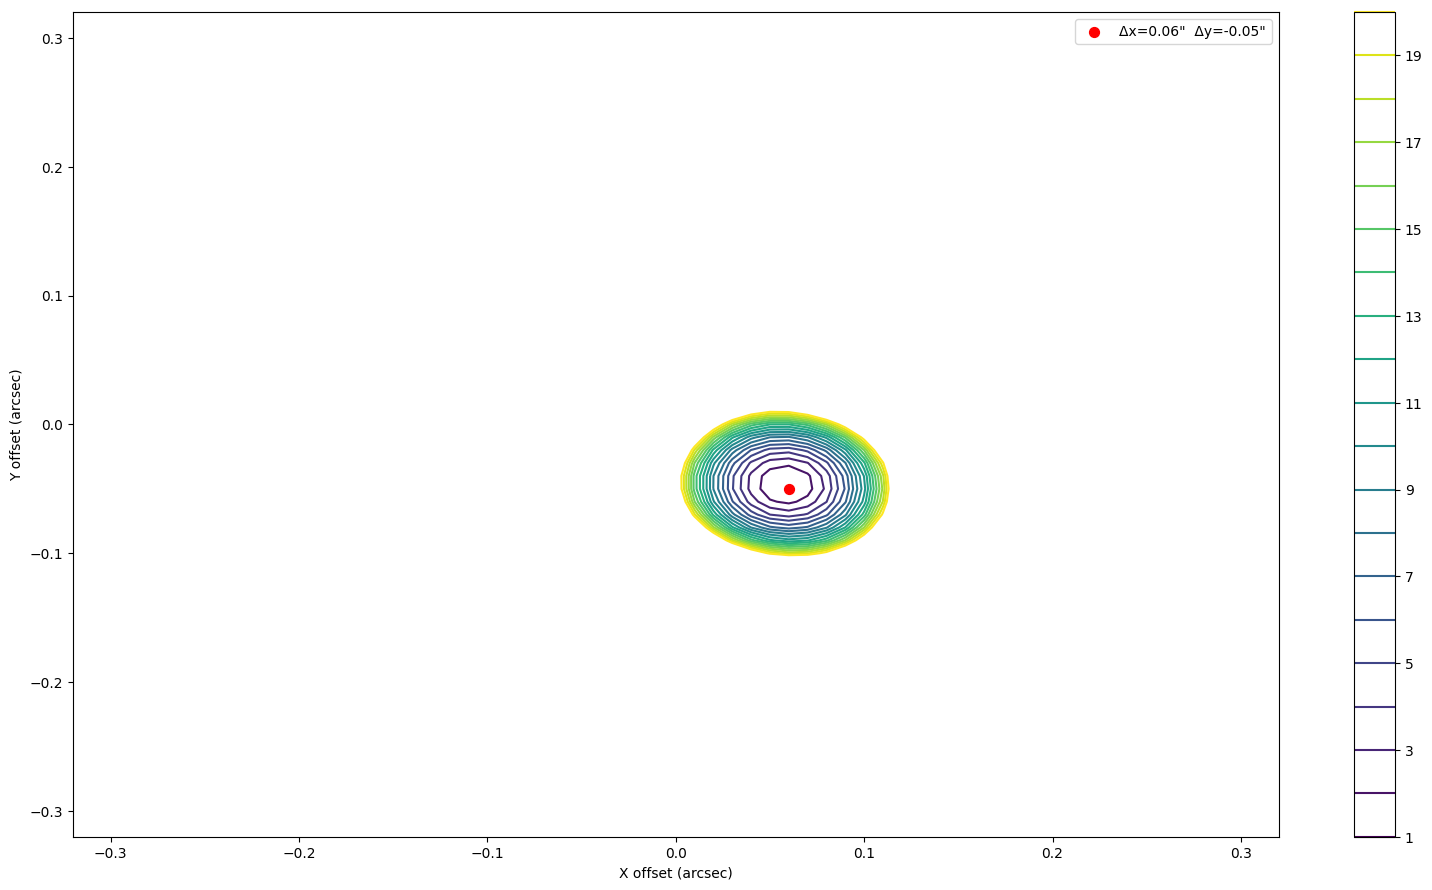

Best k: 2507
Best shift X: 0.06
Best shift Y: -0.05
fine_min_chi: 13.721208
88.95569786953395 420.682989856398


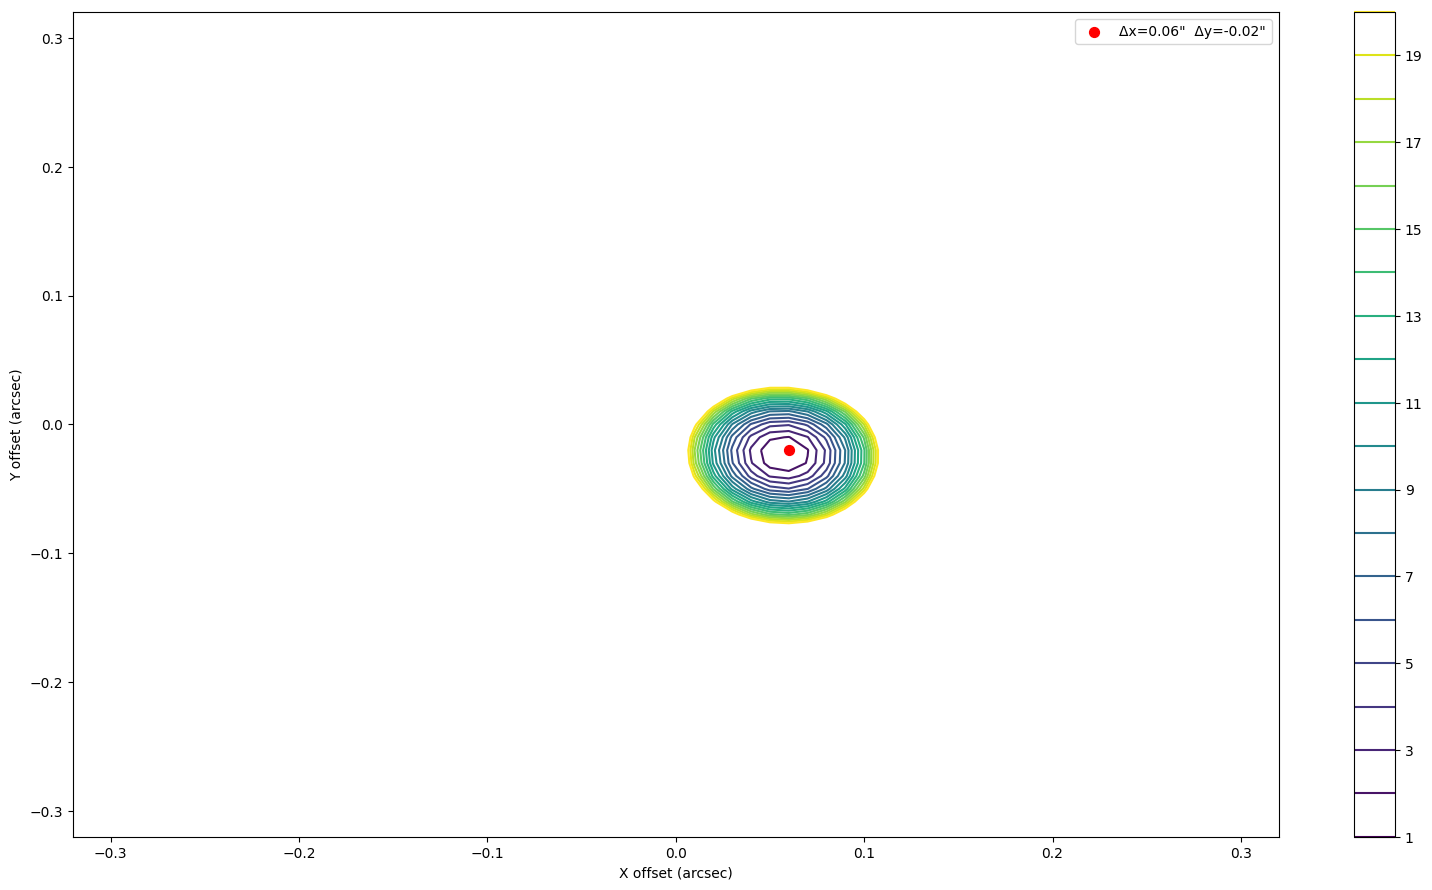

Best k: 2504
Best shift X: 0.06
Best shift Y: -0.02
fine_min_chi: 8.010940
314.84071702174435 403.682989856398


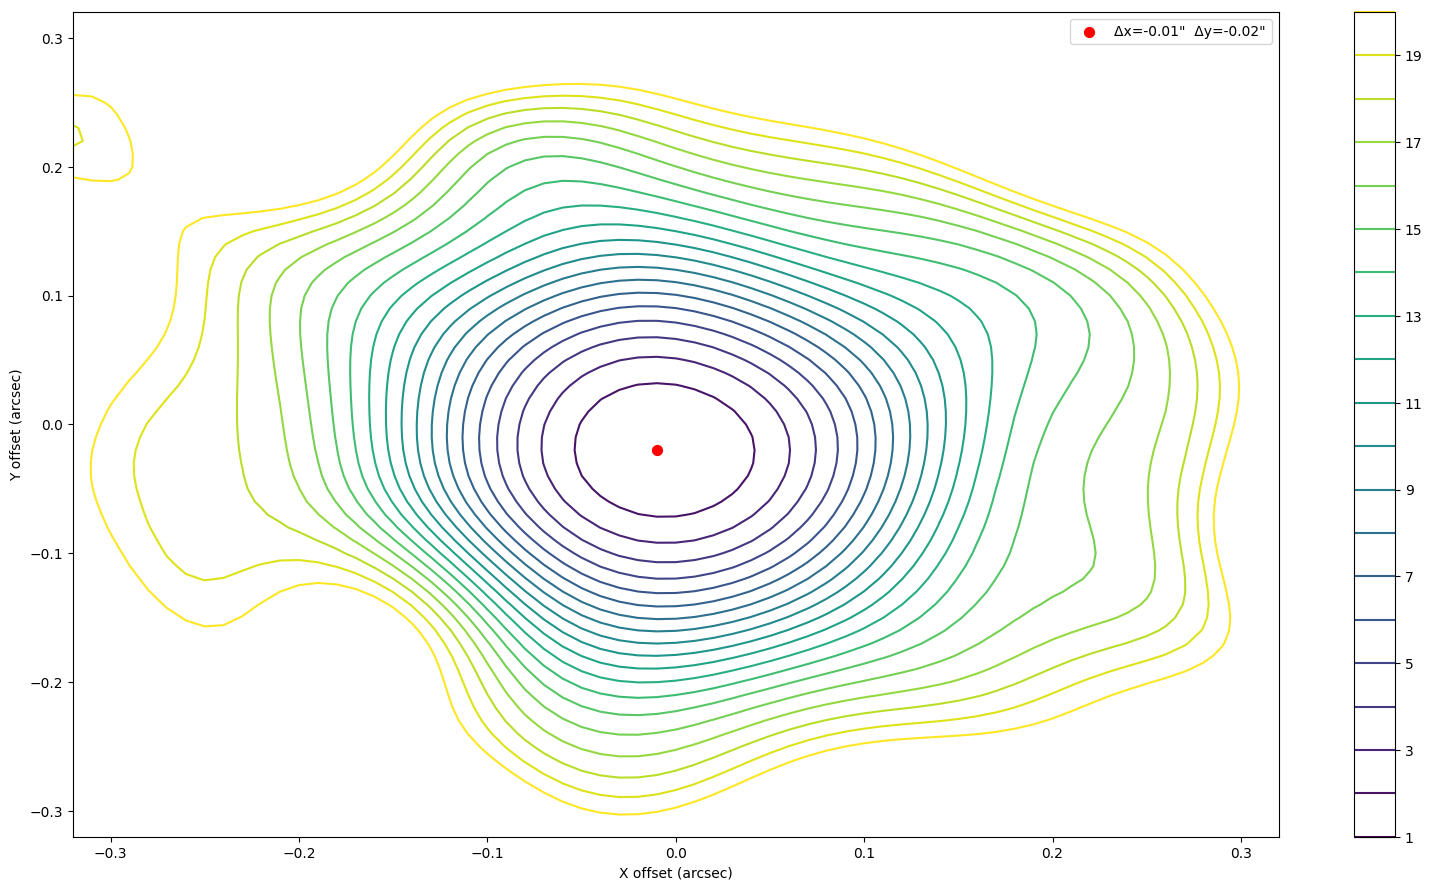

Best k: 2049
Best shift X: -0.01
Best shift Y: -0.02
fine_min_chi: 1.636062
471.63713191302264 404.524484784597


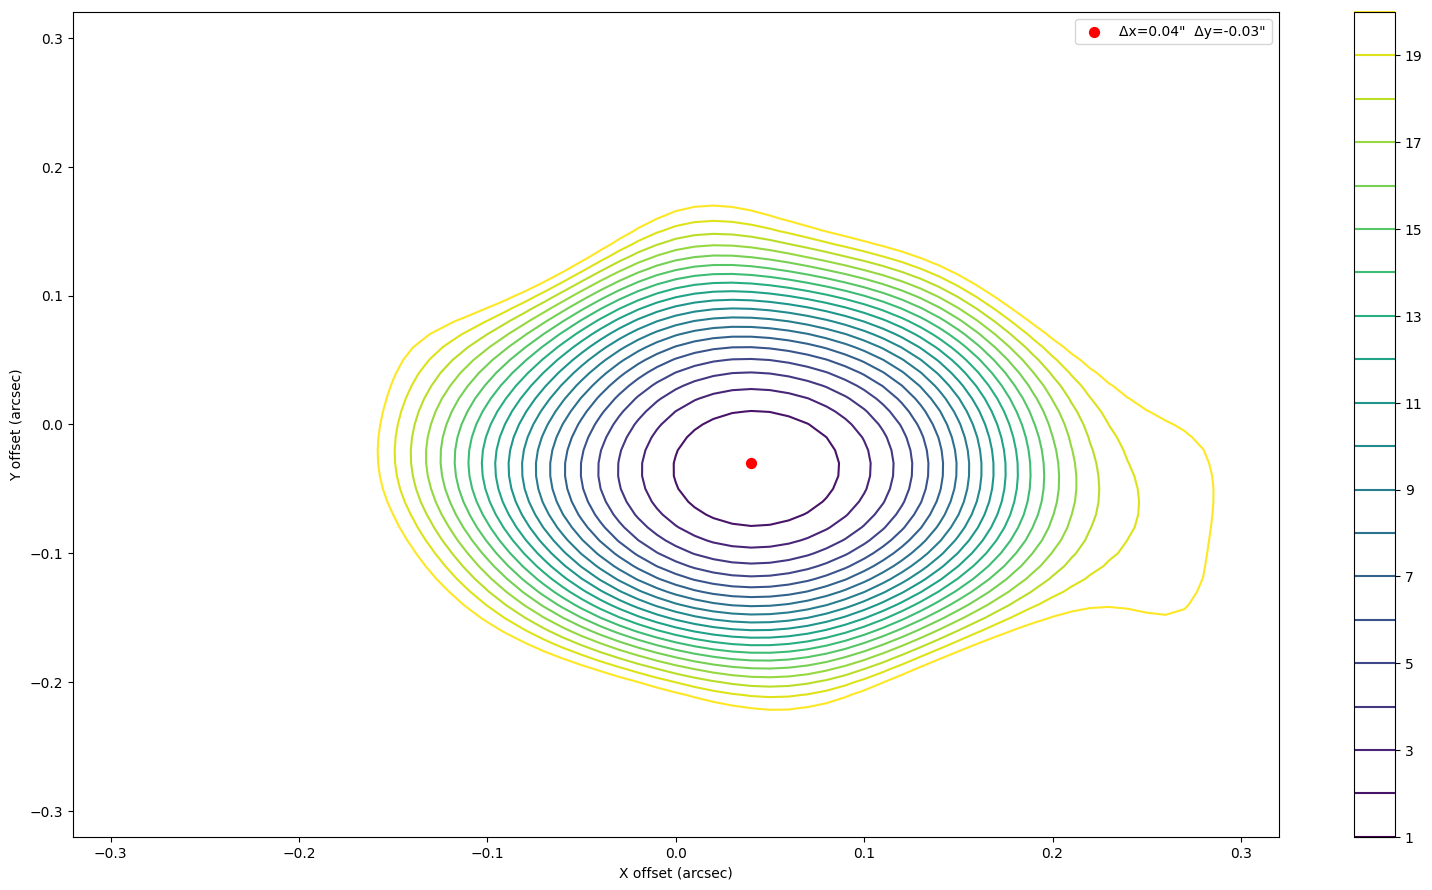

Best k: 2375
Best shift X: 0.04
Best shift Y: -0.03
fine_min_chi: 1.697131
433.3185659565113 96.04896956919401


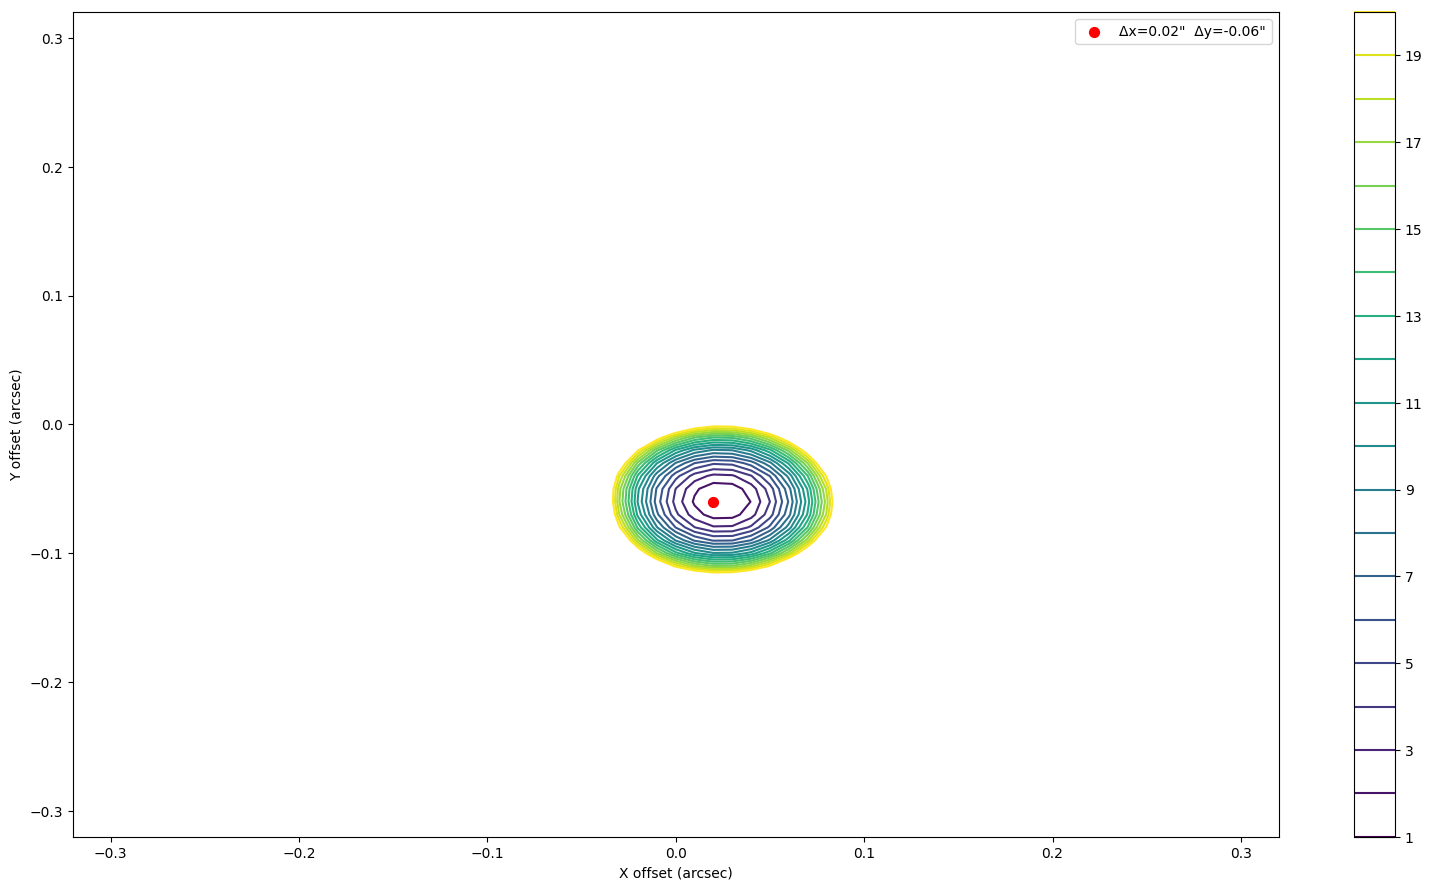

Best k: 2248
Best shift X: 0.02
Best shift Y: -0.06
fine_min_chi: 3.146155
784.6814340434887 142.89046449739303


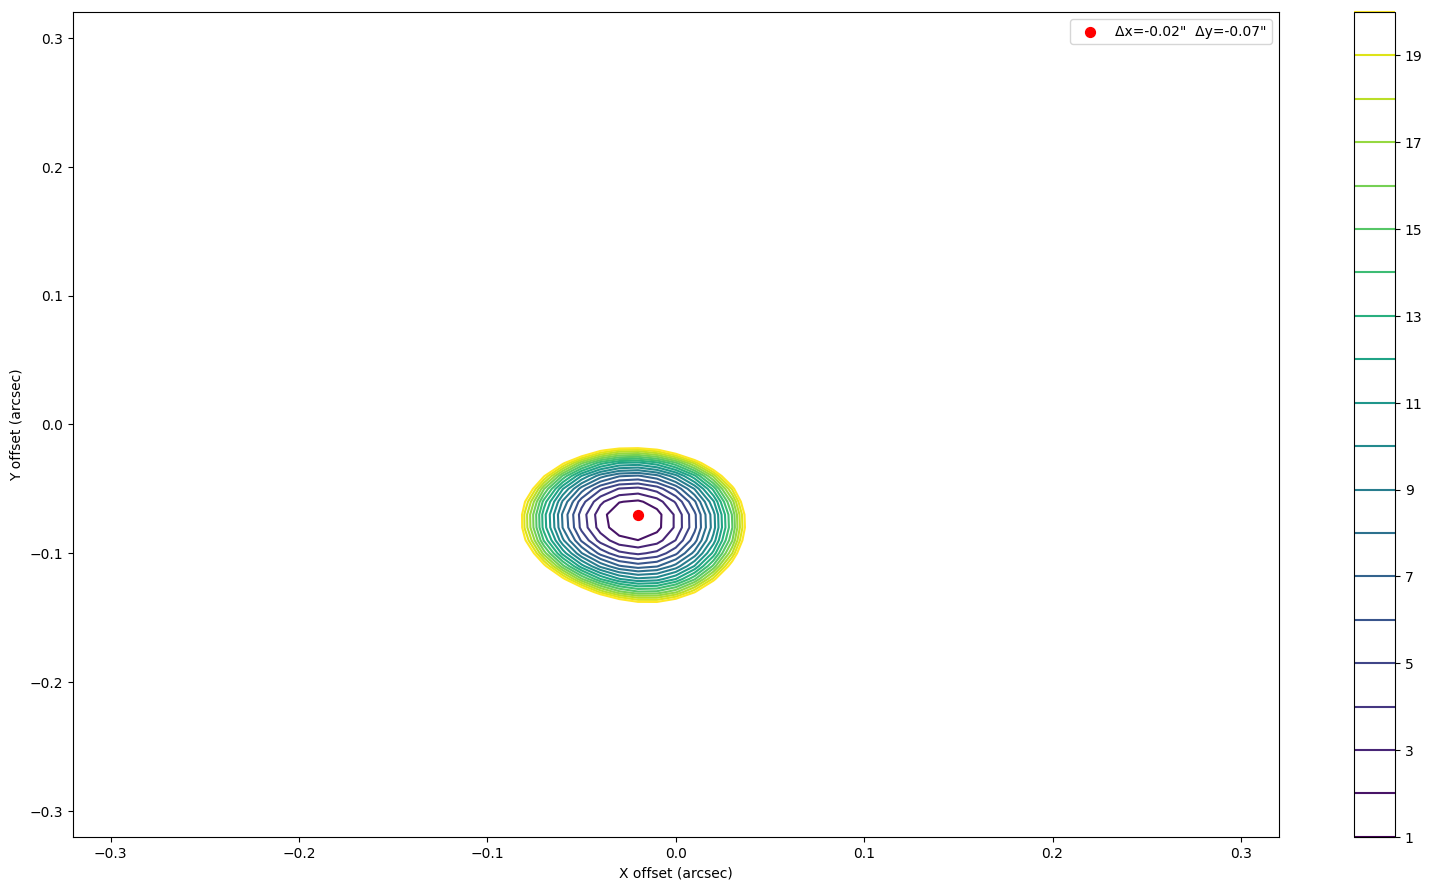

Best k: 1989
Best shift X: -0.02
Best shift Y: -0.07
fine_min_chi: 4.814321
673.4778489347669 778.365979712796


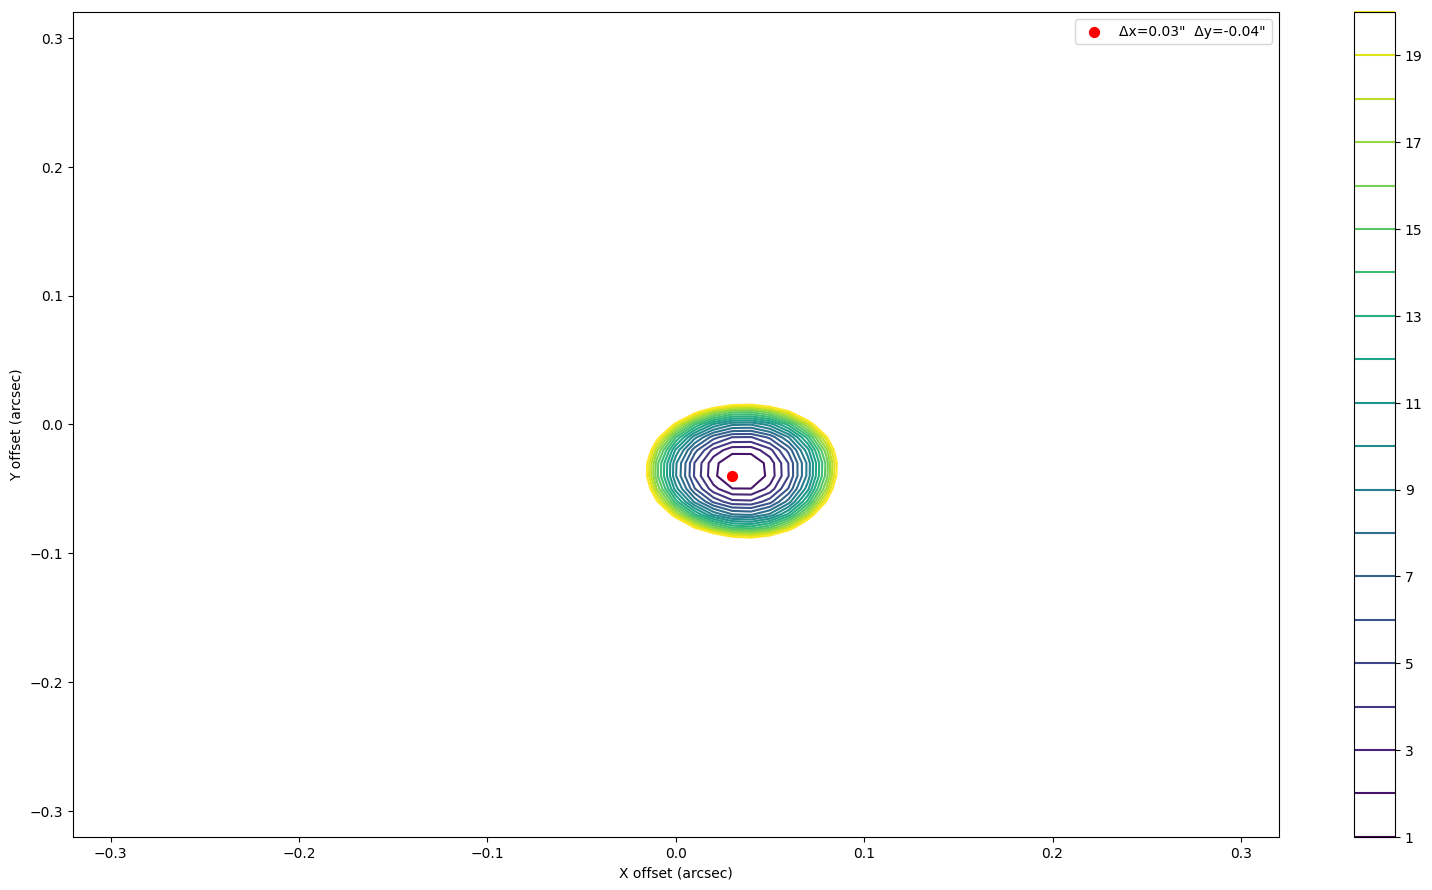

Best k: 2311
Best shift X: 0.03
Best shift Y: -0.04
fine_min_chi: 9.008542
1161.522151065233 874.475515215403


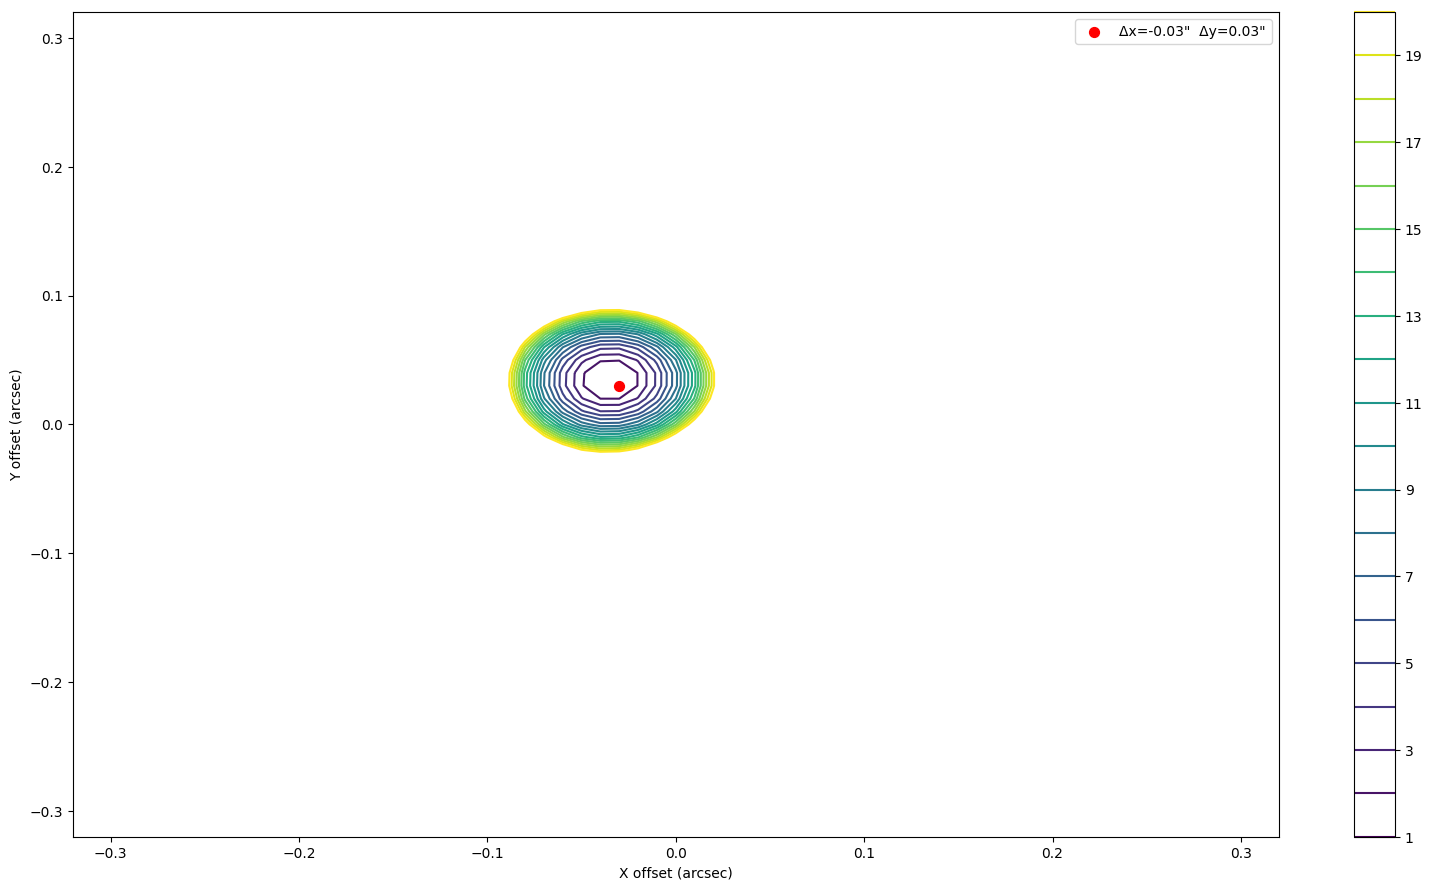

Best k: 1914
Best shift X: -0.03
Best shift Y: 0.03
fine_min_chi: 4.273891
177.68143404348868 1910.317010143602


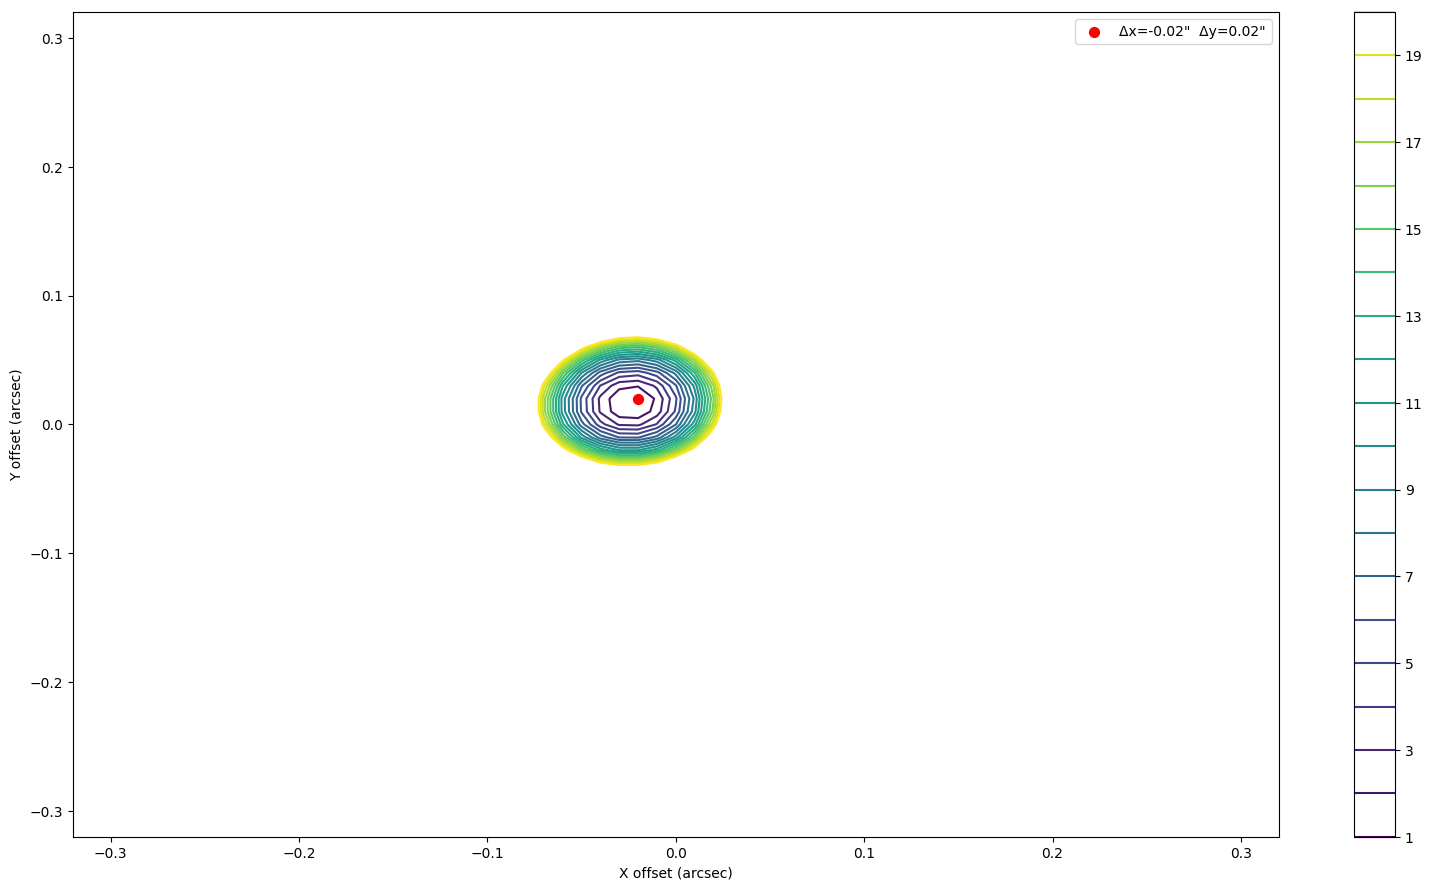

Best k: 1980
Best shift X: -0.02
Best shift Y: 0.02
fine_min_chi: 6.097983
1311.8407170217442 1752.317010143602


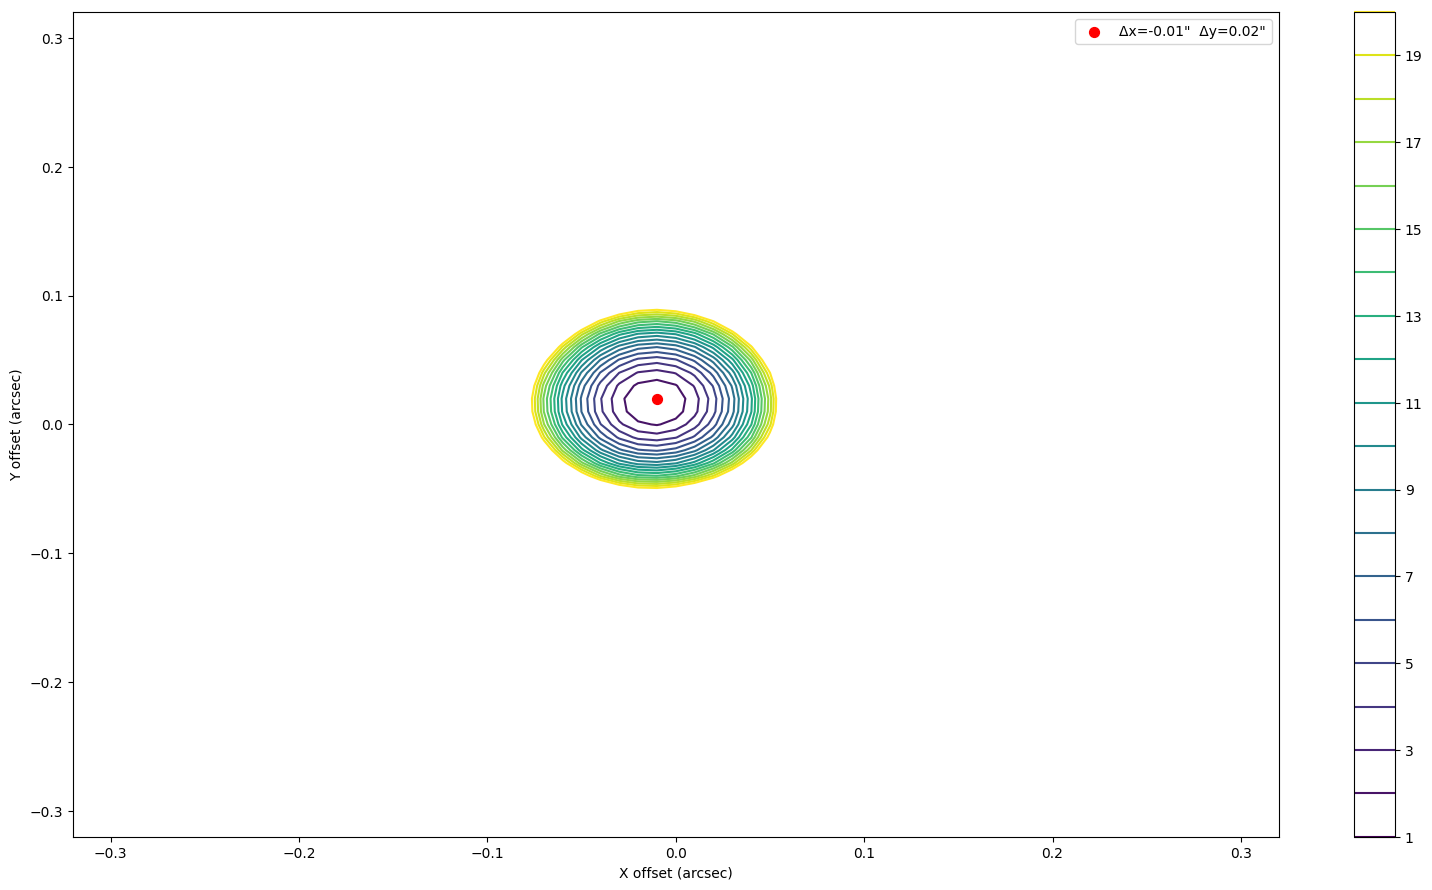

Best k: 2045
Best shift X: -0.01
Best shift Y: 0.02
fine_min_chi: 4.546295
1688.522151065233 1090.951030430806


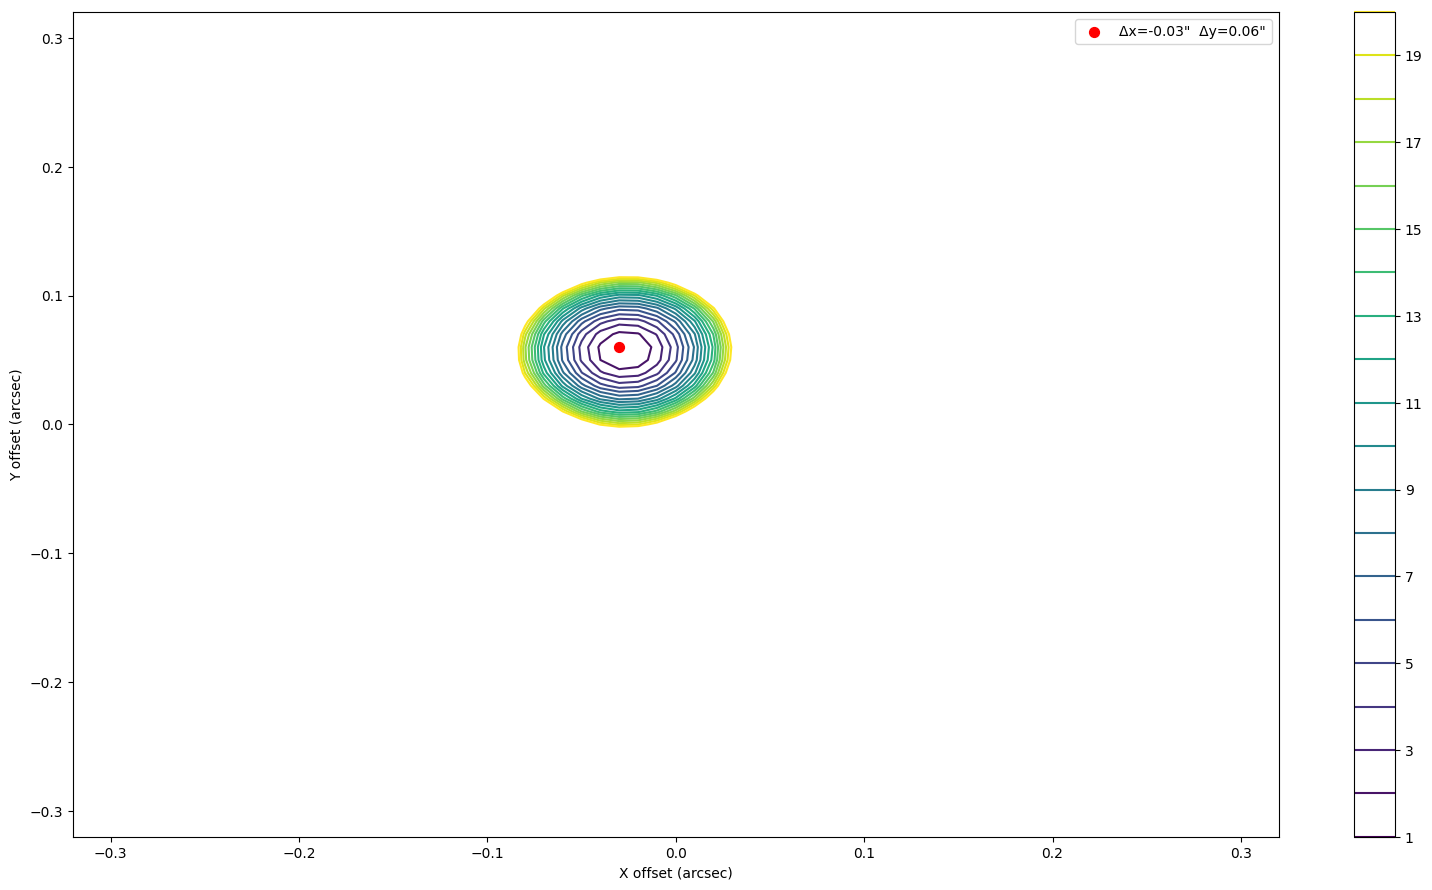

Best k: 1911
Best shift X: -0.03
Best shift Y: 0.06
fine_min_chi: 9.295329
1777.2035851087217 966.365979712796


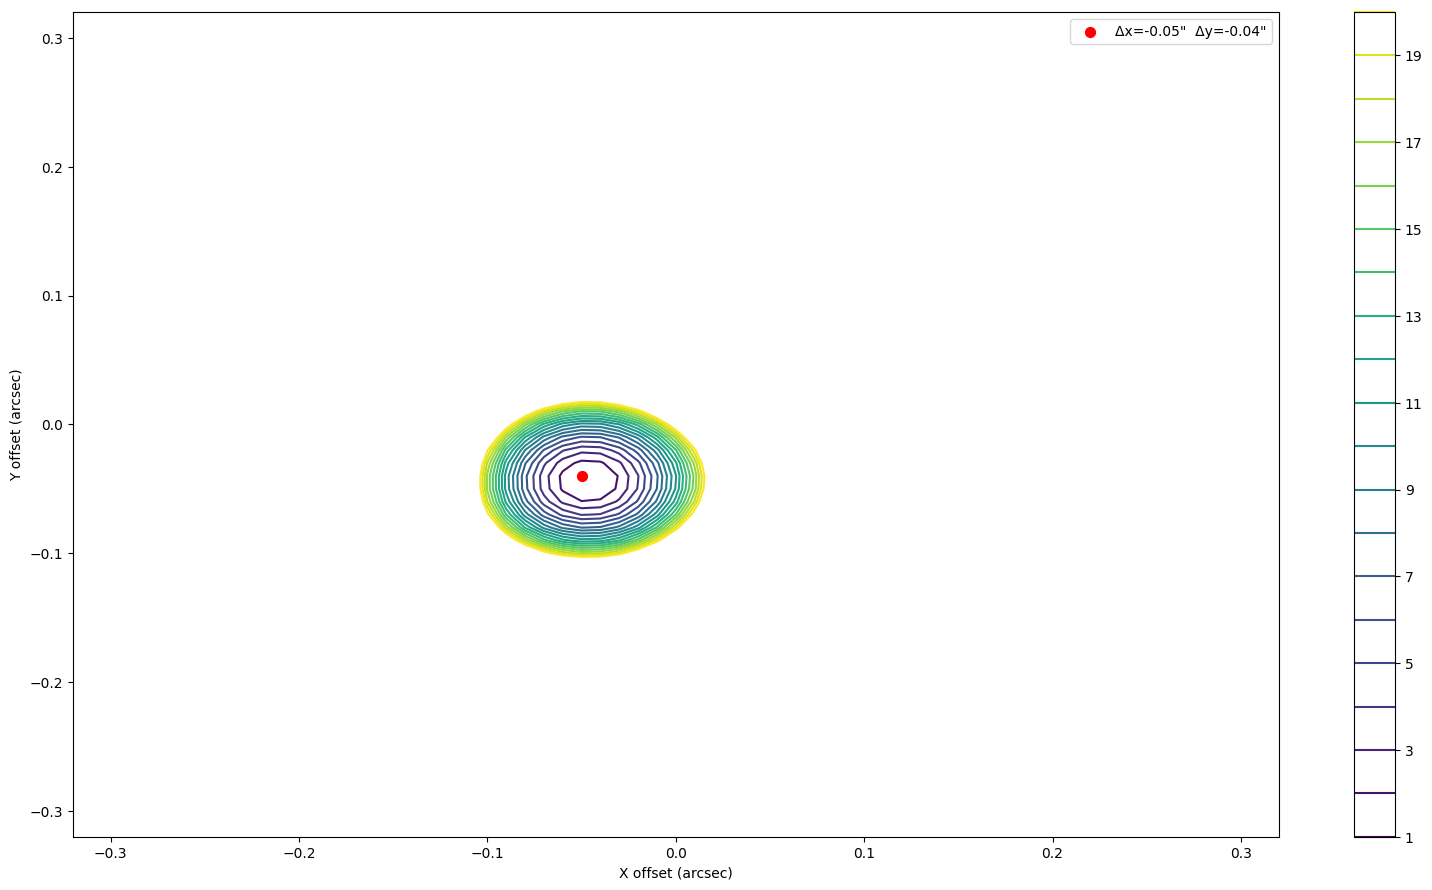

Best k: 1791
Best shift X: -0.05
Best shift Y: -0.04
fine_min_chi: 6.887778
1965.477848934767 1054.682989856398


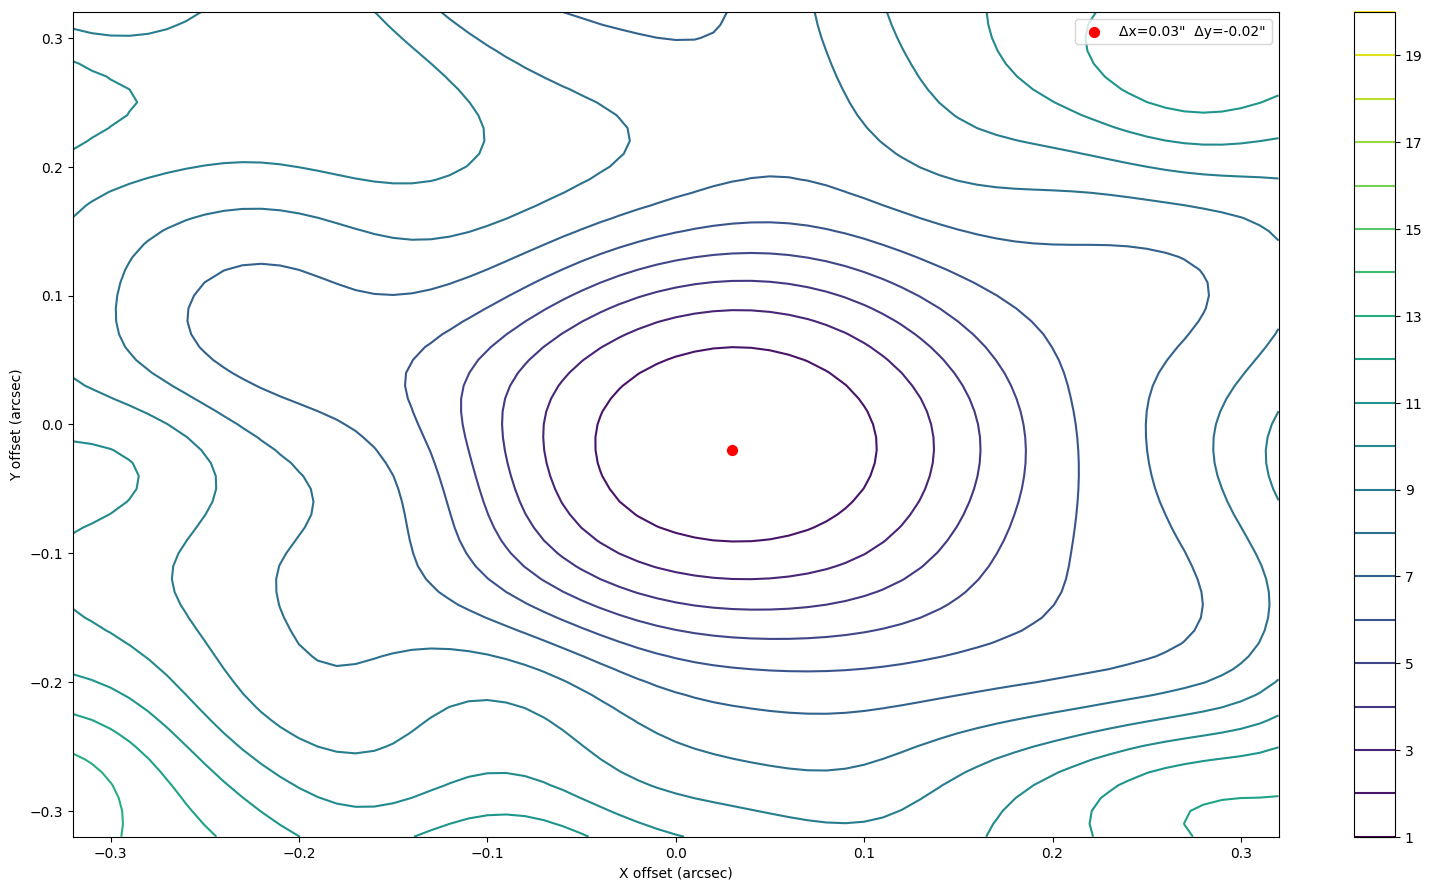

Best k: 2309
Best shift X: 0.03
Best shift Y: -0.02
fine_min_chi: 2.027032
2001.522151065233 481.951030430806


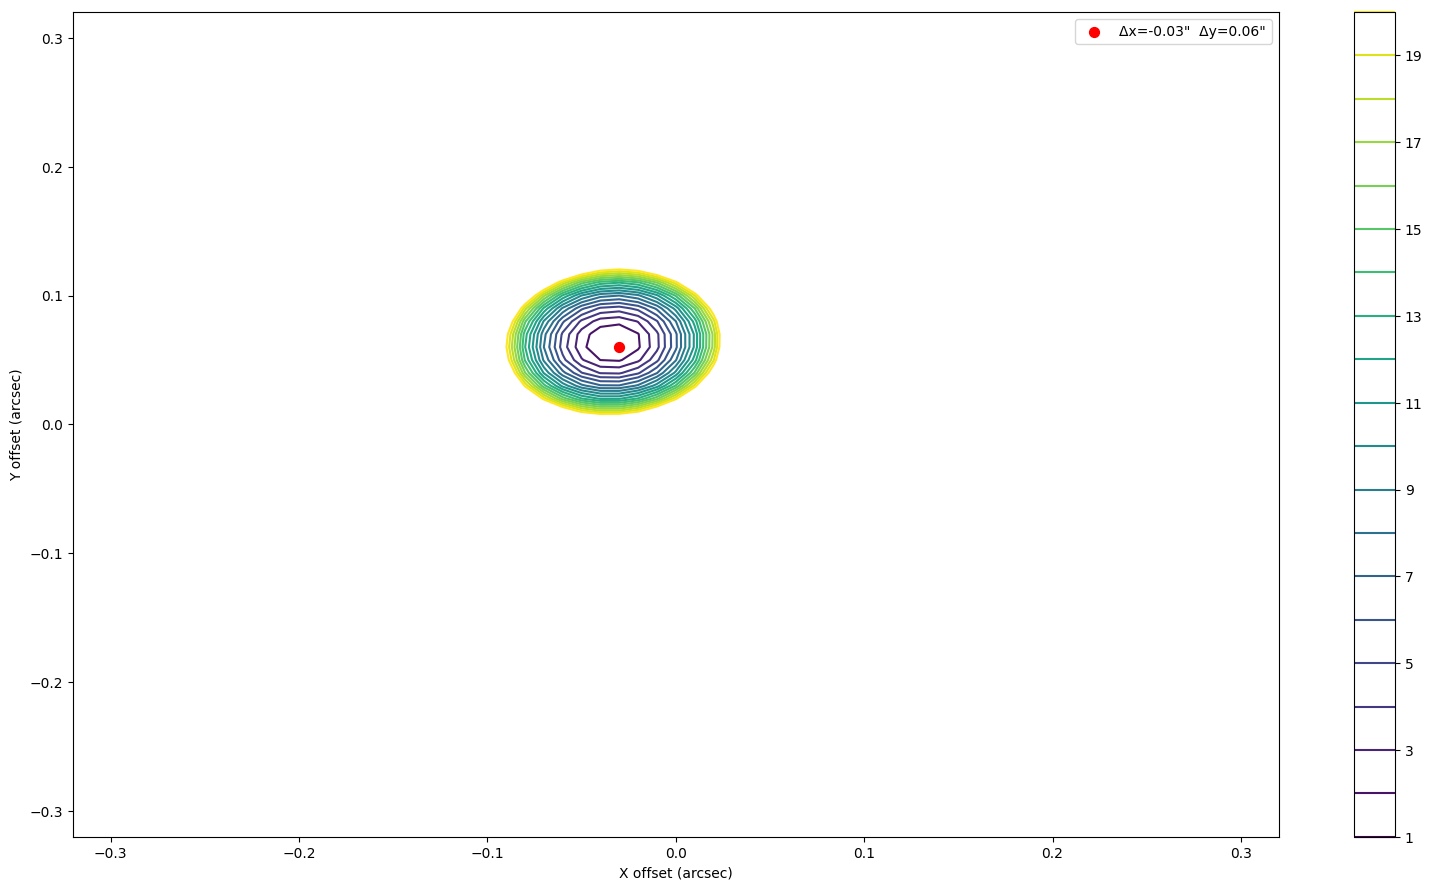

Best k: 1911
Best shift X: -0.03
Best shift Y: 0.06
fine_min_chi: 4.698402


In [7]:

best_x = []
best_y = []
min_chi = []

n = np.zeros(1)

for k in range(len(x_coords)):
    bestl_x, bestl_y, min_chil, s, l, j = psf_fitting(x_coords[k], y_coords[k], hdu_c_psf)
    best_x.append(bestl_x)
    best_y.append(bestl_y)
    min_chi.append(min_chil)

41.93628680869774 430.2694586220617


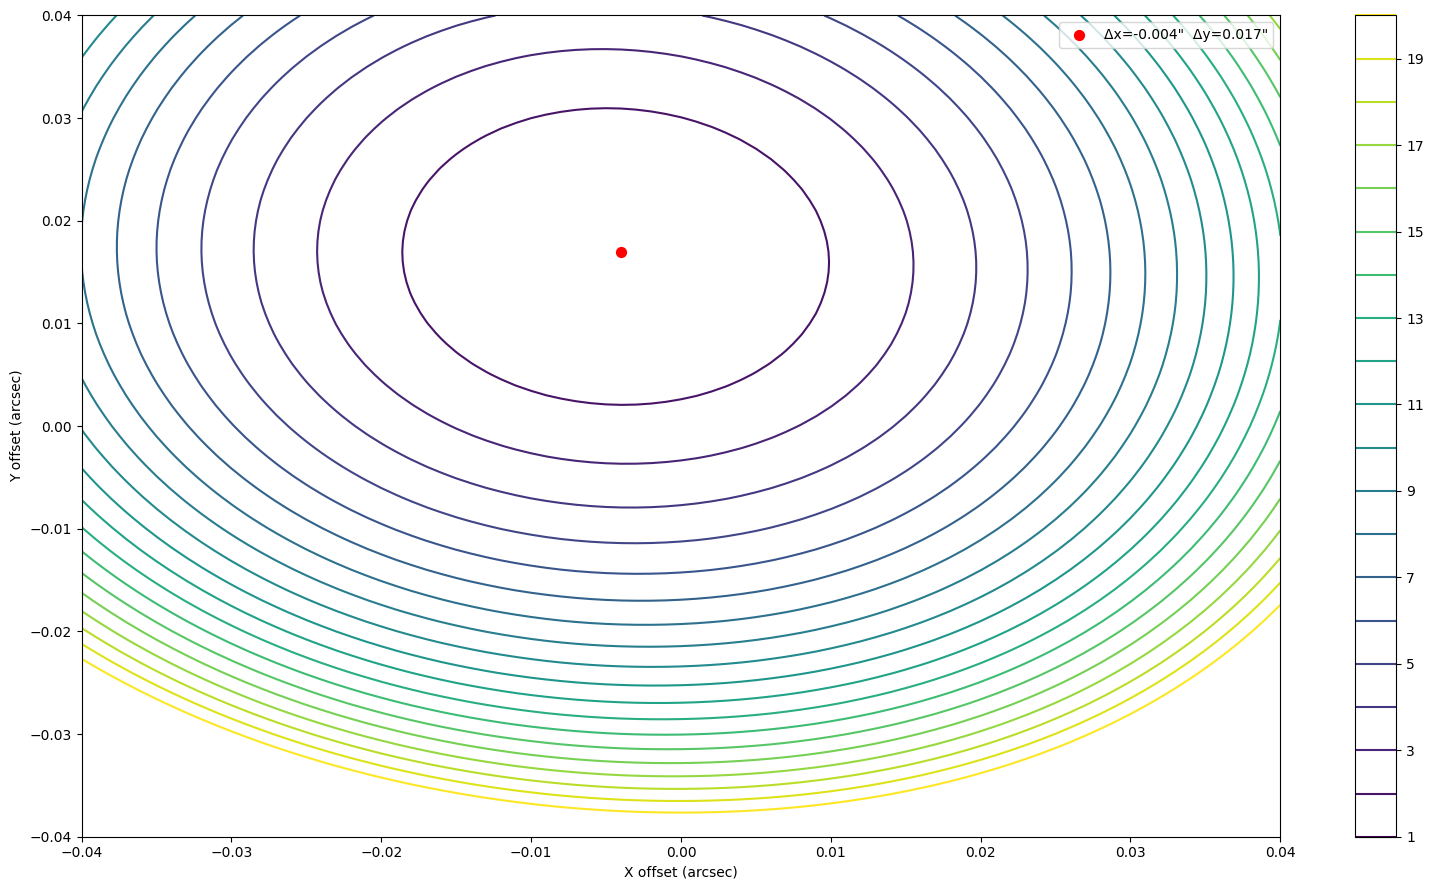

Best k: 2939
Best shift X: -0.004
Best shift Y: 0.017
fine_min_chi: 13.055607
88.92035851087218 420.6354383348577


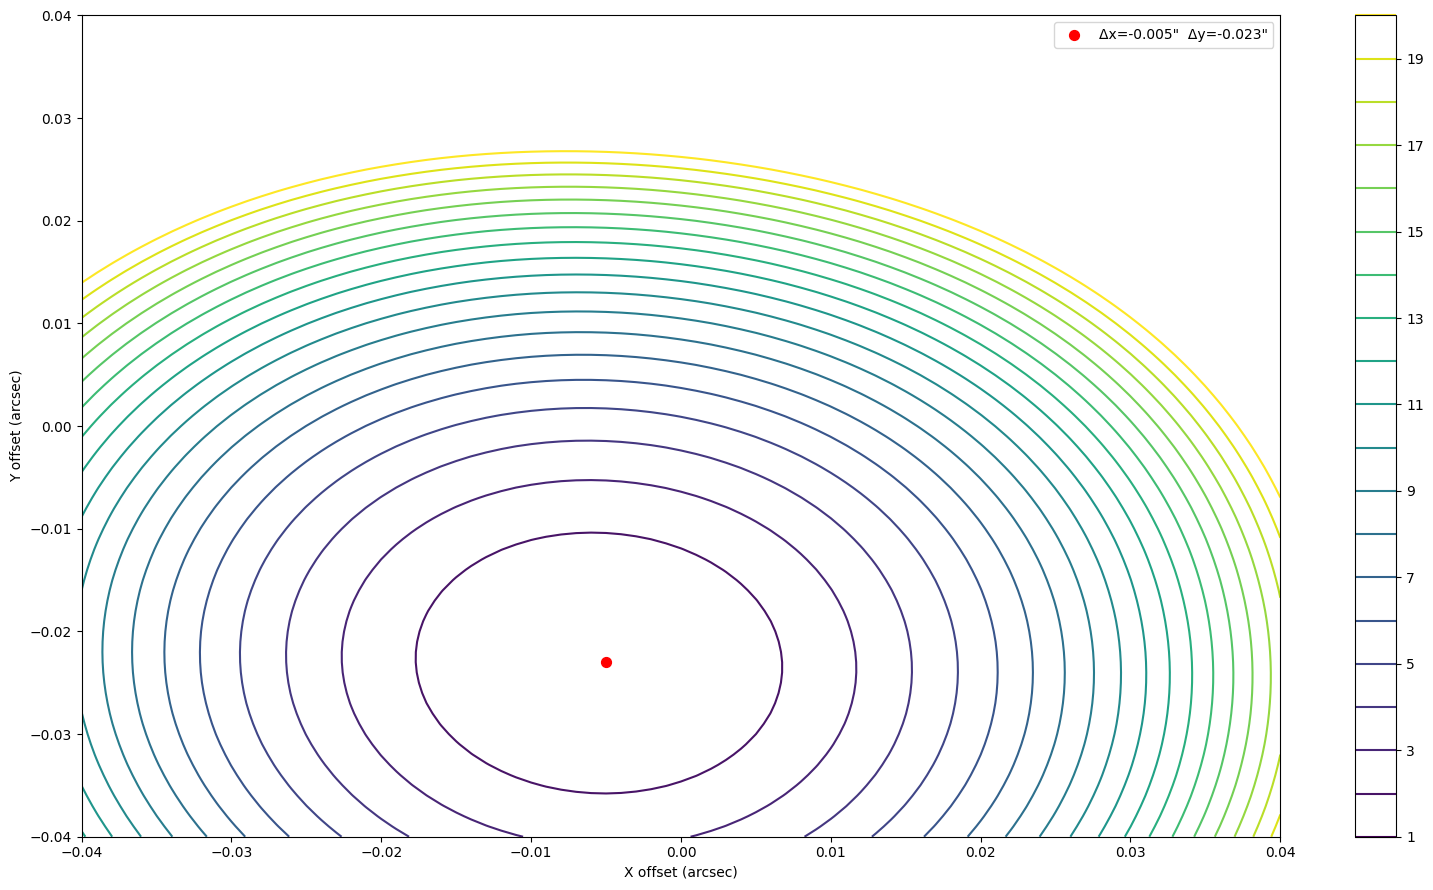

Best k: 2898
Best shift X: -0.005
Best shift Y: -0.023
fine_min_chi: 7.233892
314.888501915221 403.682989856398


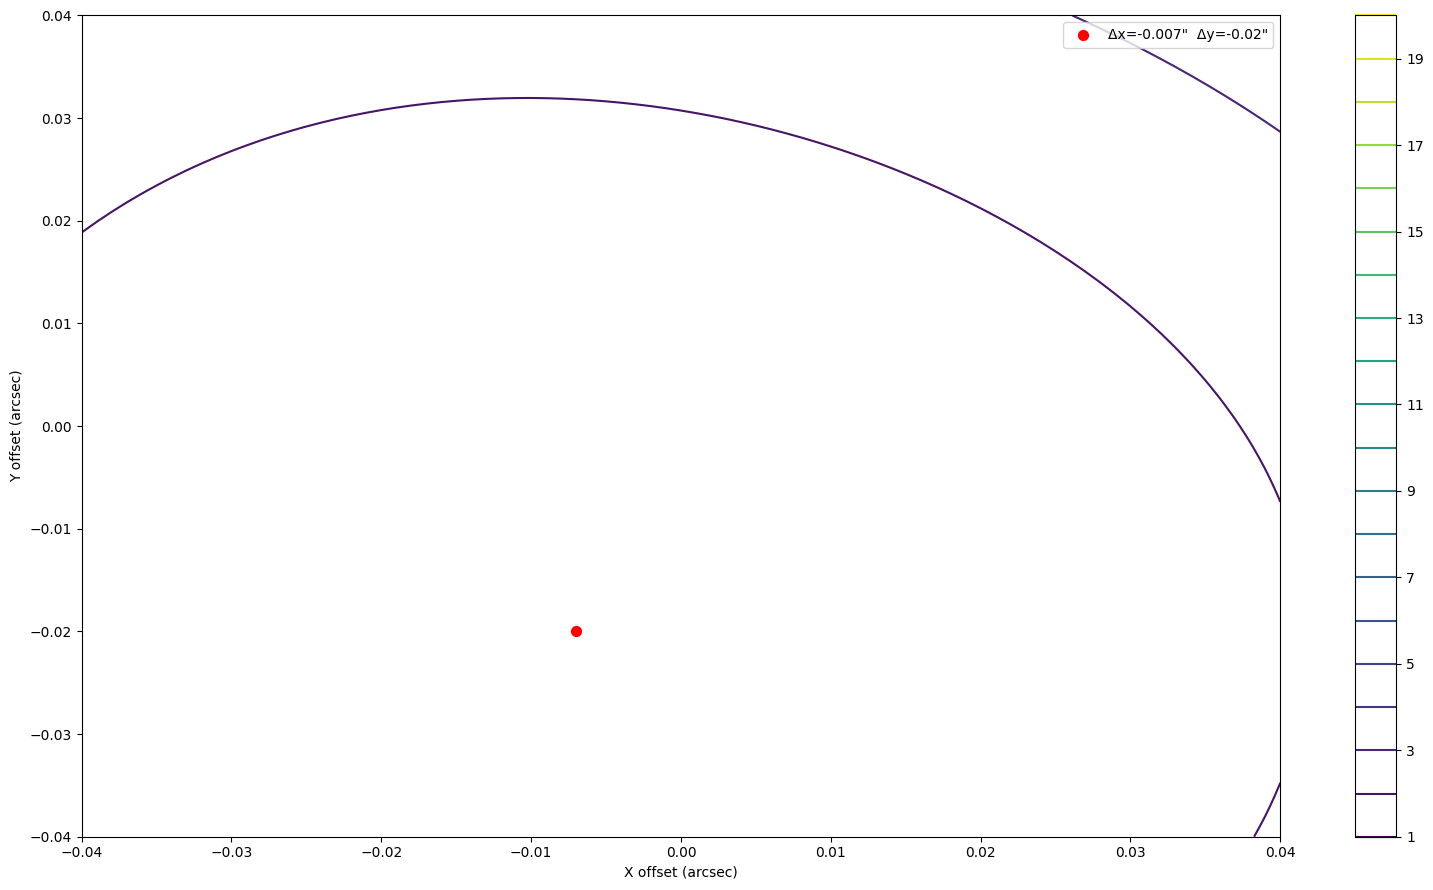

Best k: 2733
Best shift X: -0.007
Best shift Y: -0.02
fine_min_chi: 1.629950
471.6814340434887 404.4610827558766


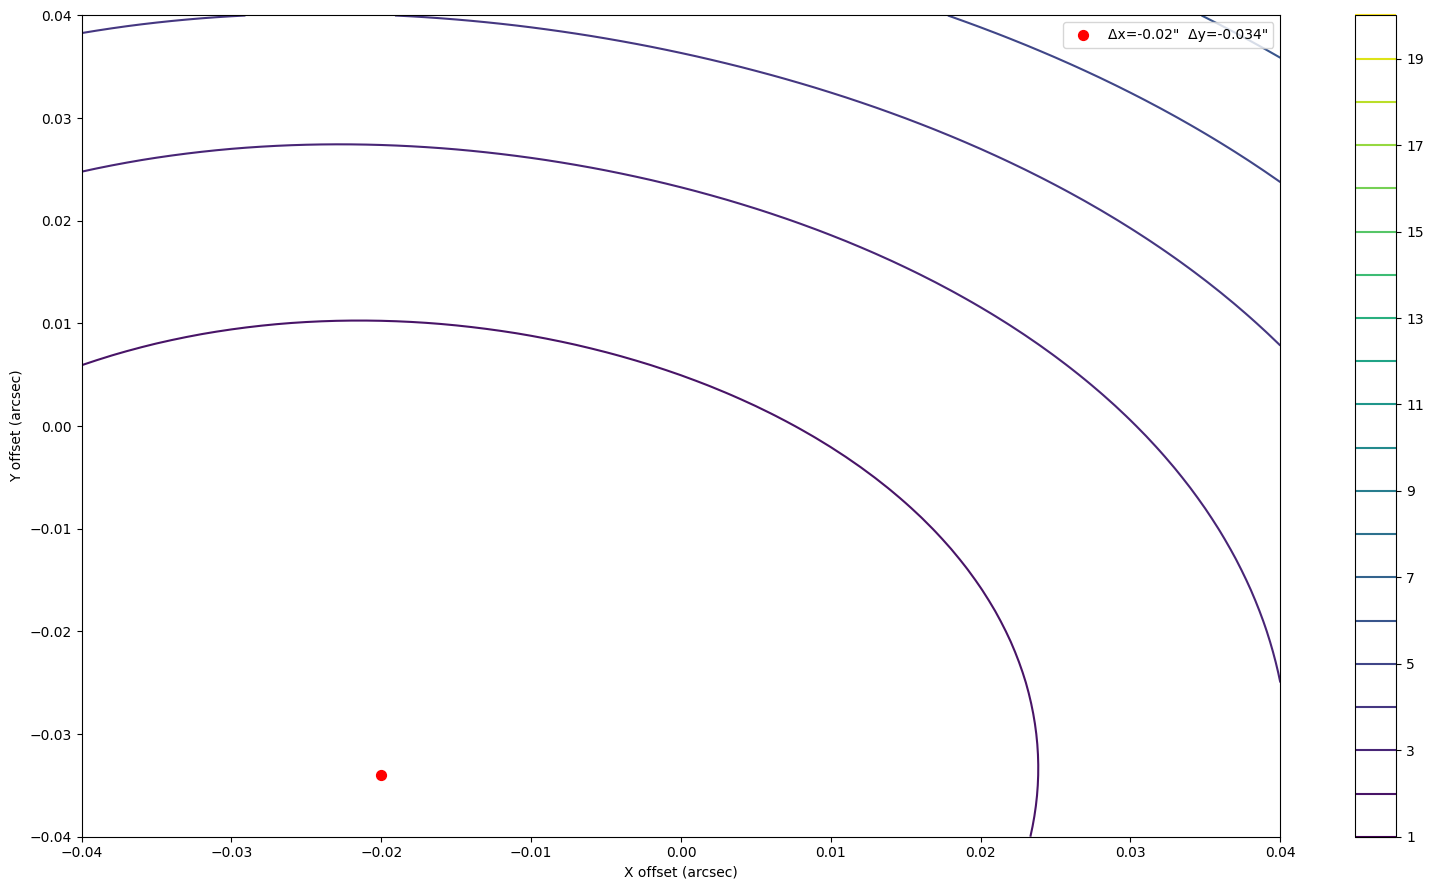

Best k: 1694
Best shift X: -0.02
Best shift Y: -0.034
fine_min_chi: 1.680789
433.38227914781356 96.0634020287204


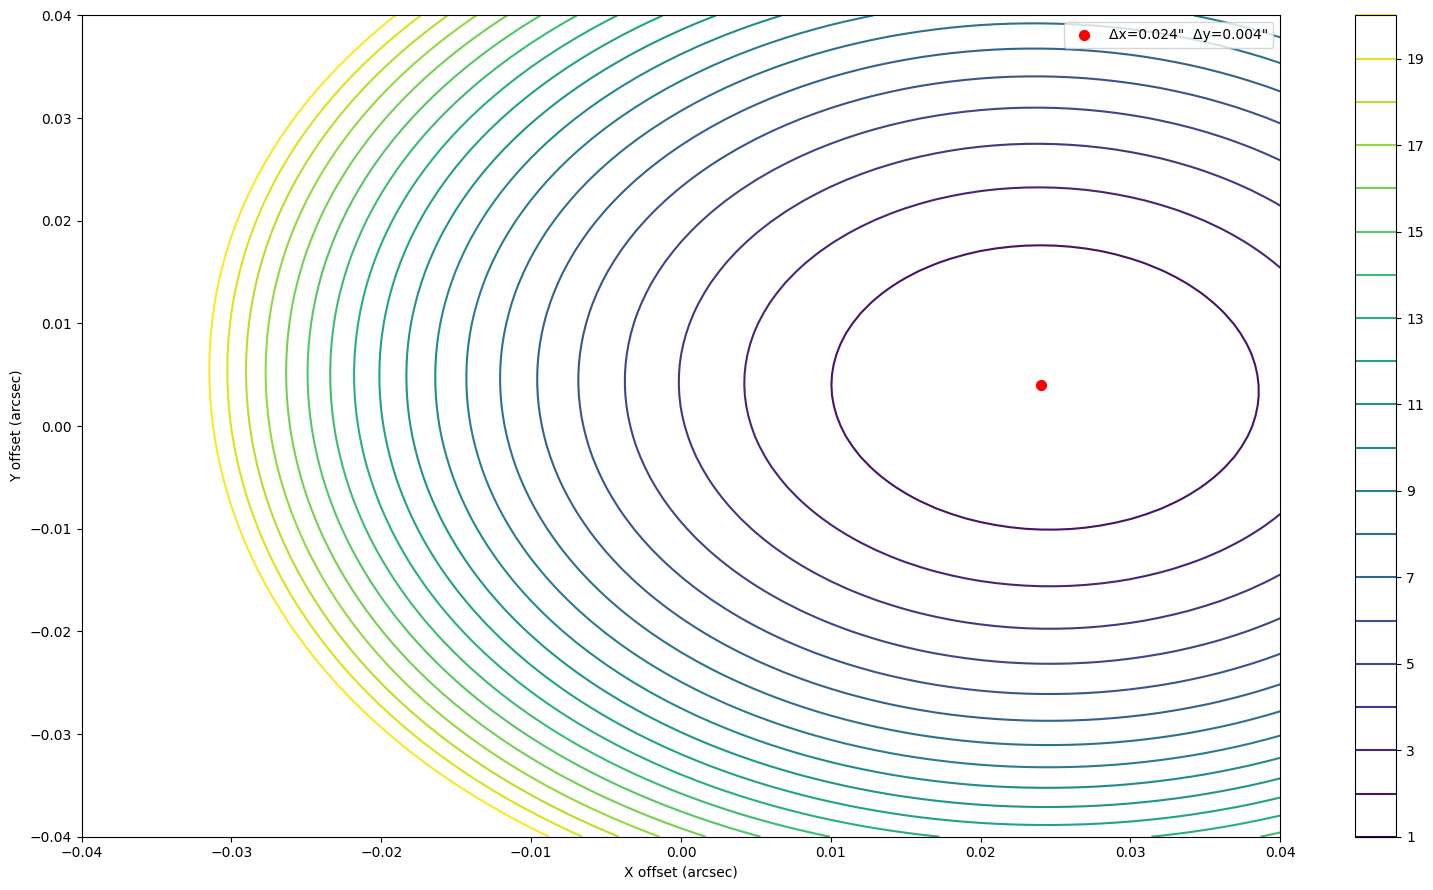

Best k: 5220
Best shift X: 0.024
Best shift Y: 0.004
fine_min_chi: 2.863928
784.6495774478376 142.8256444210189


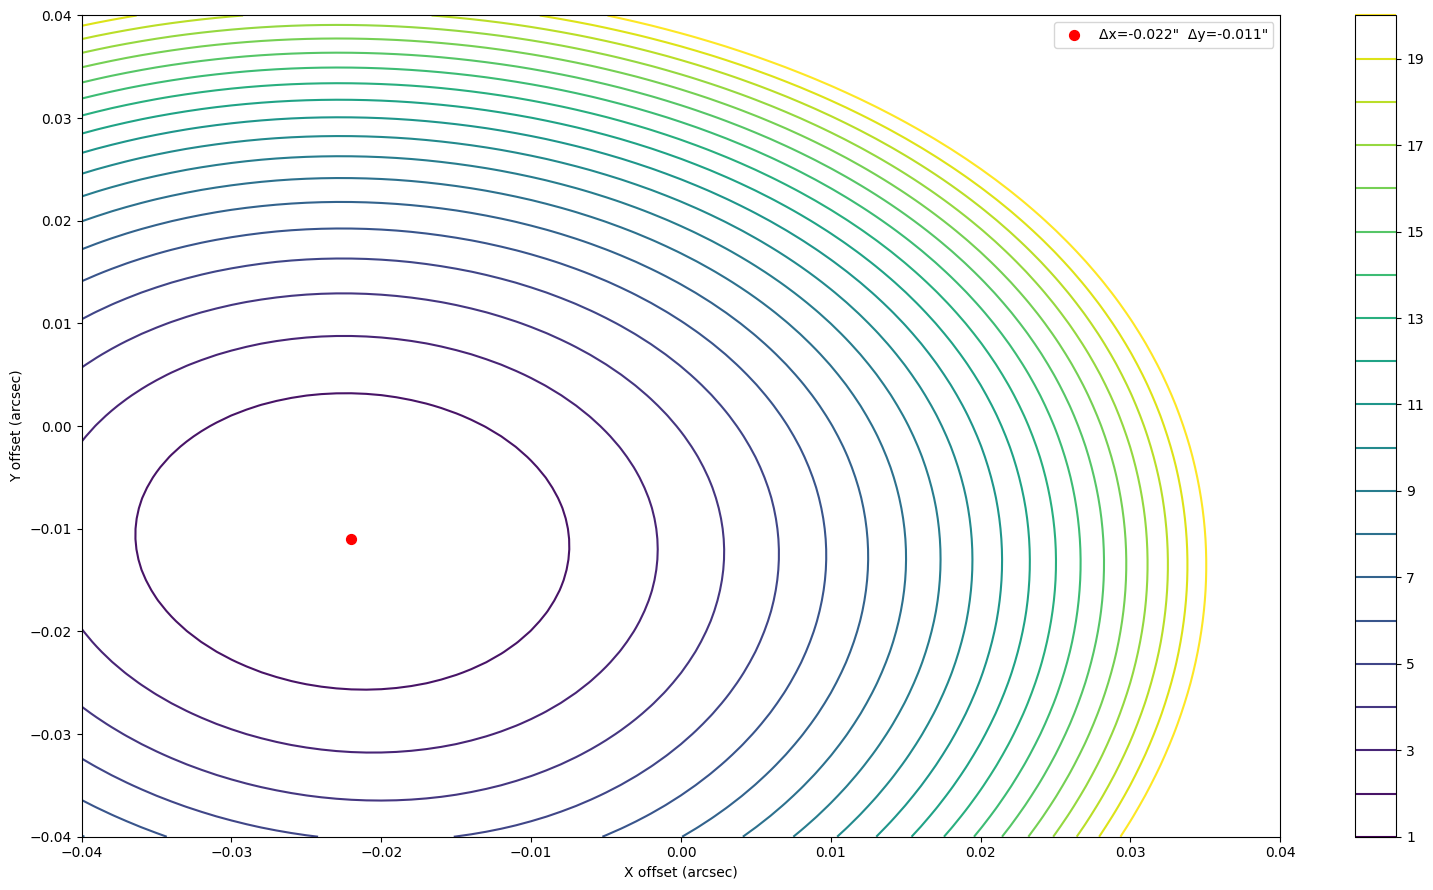

Best k: 1509
Best shift X: -0.022
Best shift Y: -0.011
fine_min_chi: 4.415488
673.5574904238948 778.4279636938627


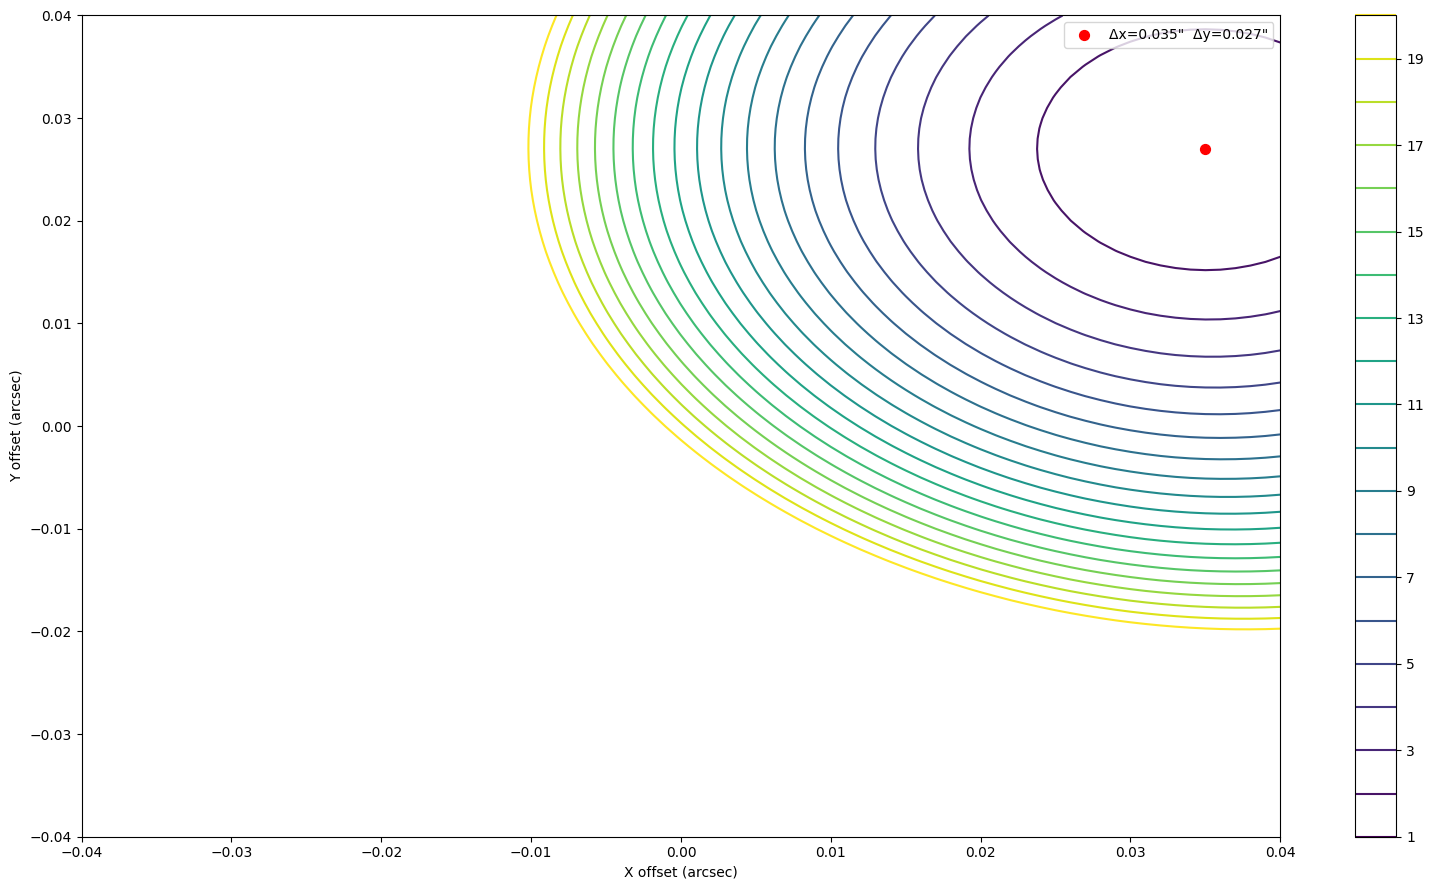

Best k: 6088
Best shift X: 0.035
Best shift Y: 0.027
fine_min_chi: 6.912391
1161.4425095761053 874.5547677513035


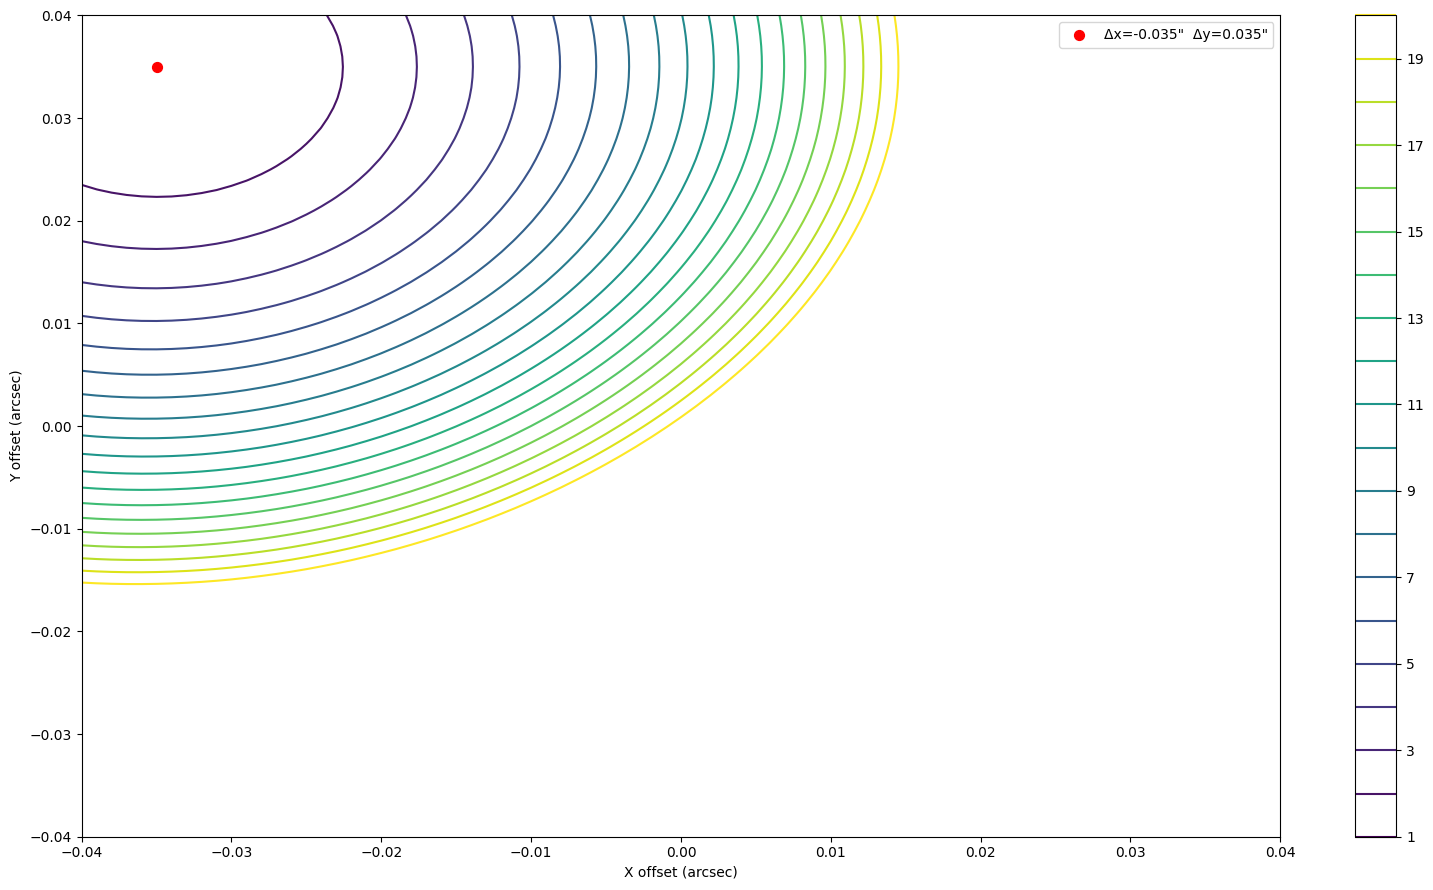

Best k: 410
Best shift X: -0.035
Best shift Y: 0.035
fine_min_chi: 3.290662
177.6177208521864 1910.2536081148817


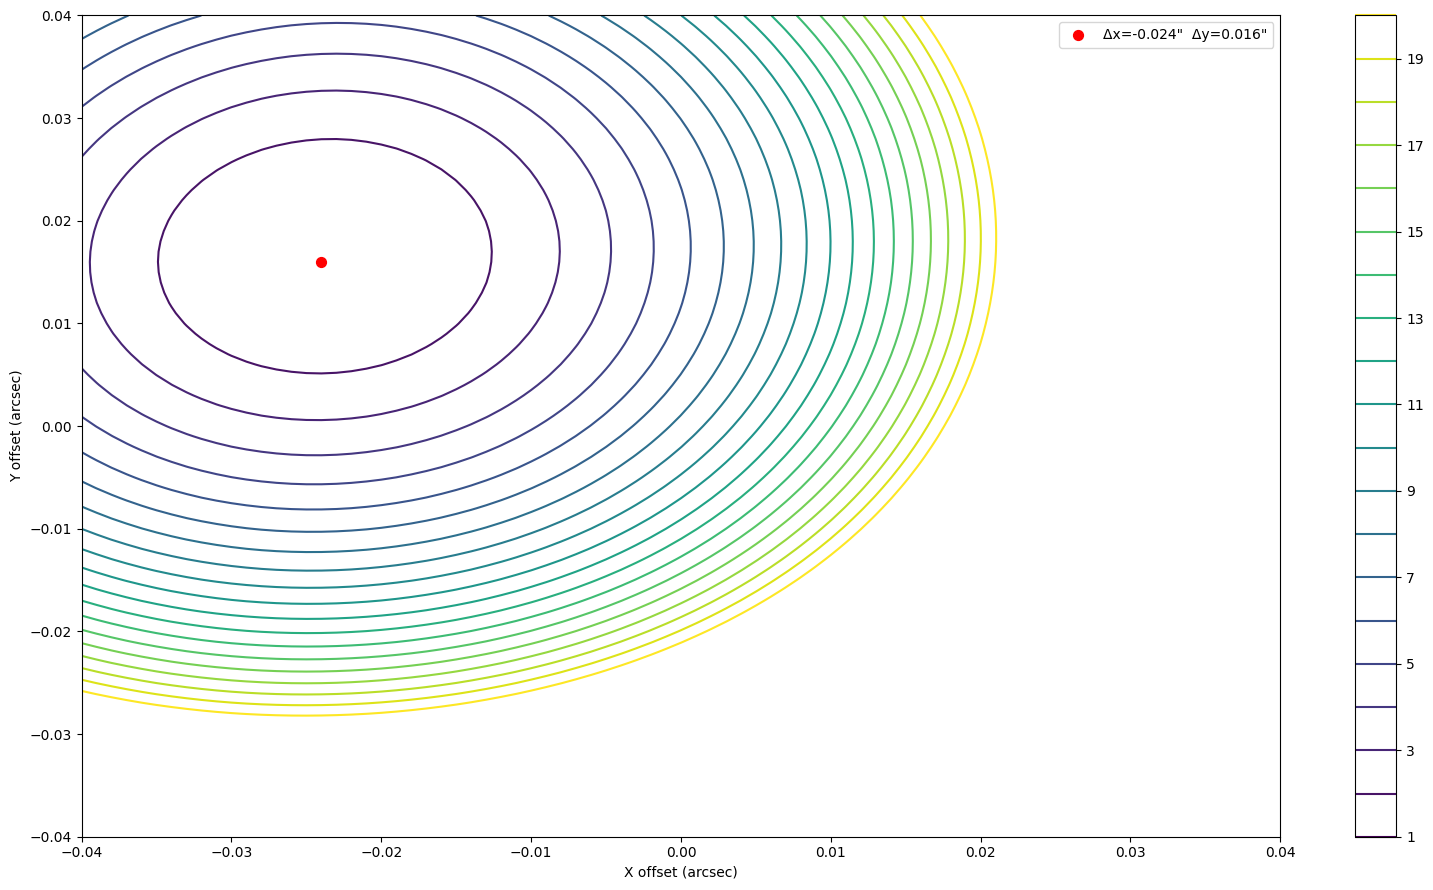

Best k: 1320
Best shift X: -0.024
Best shift Y: 0.016
fine_min_chi: 5.089440
1311.8247887239188 1752.2694586220616


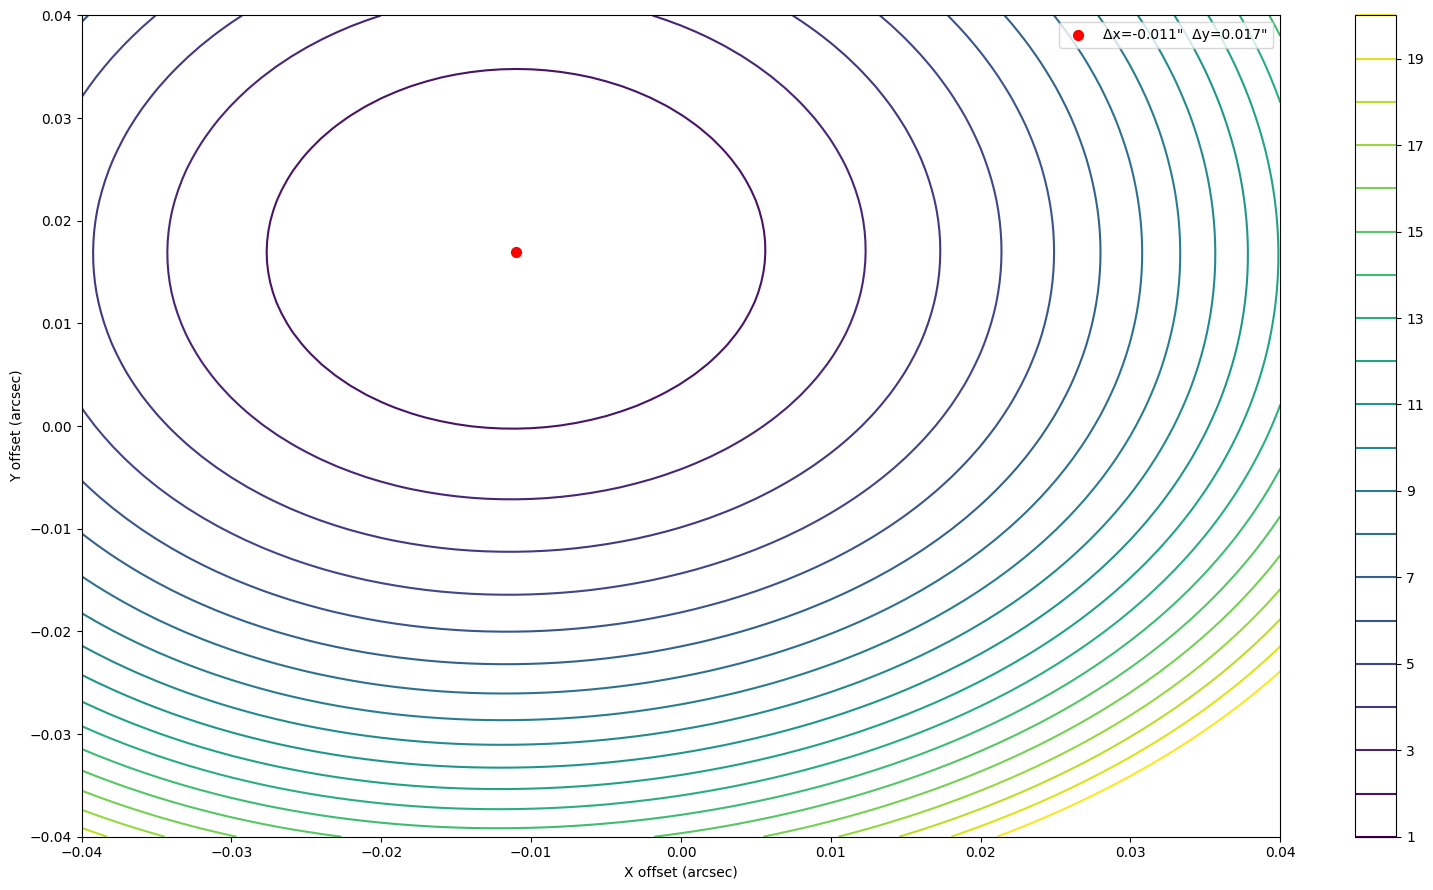

Best k: 2372
Best shift X: -0.011
Best shift Y: 0.017
fine_min_chi: 4.411868
1688.5699359587097 1090.9048969569194


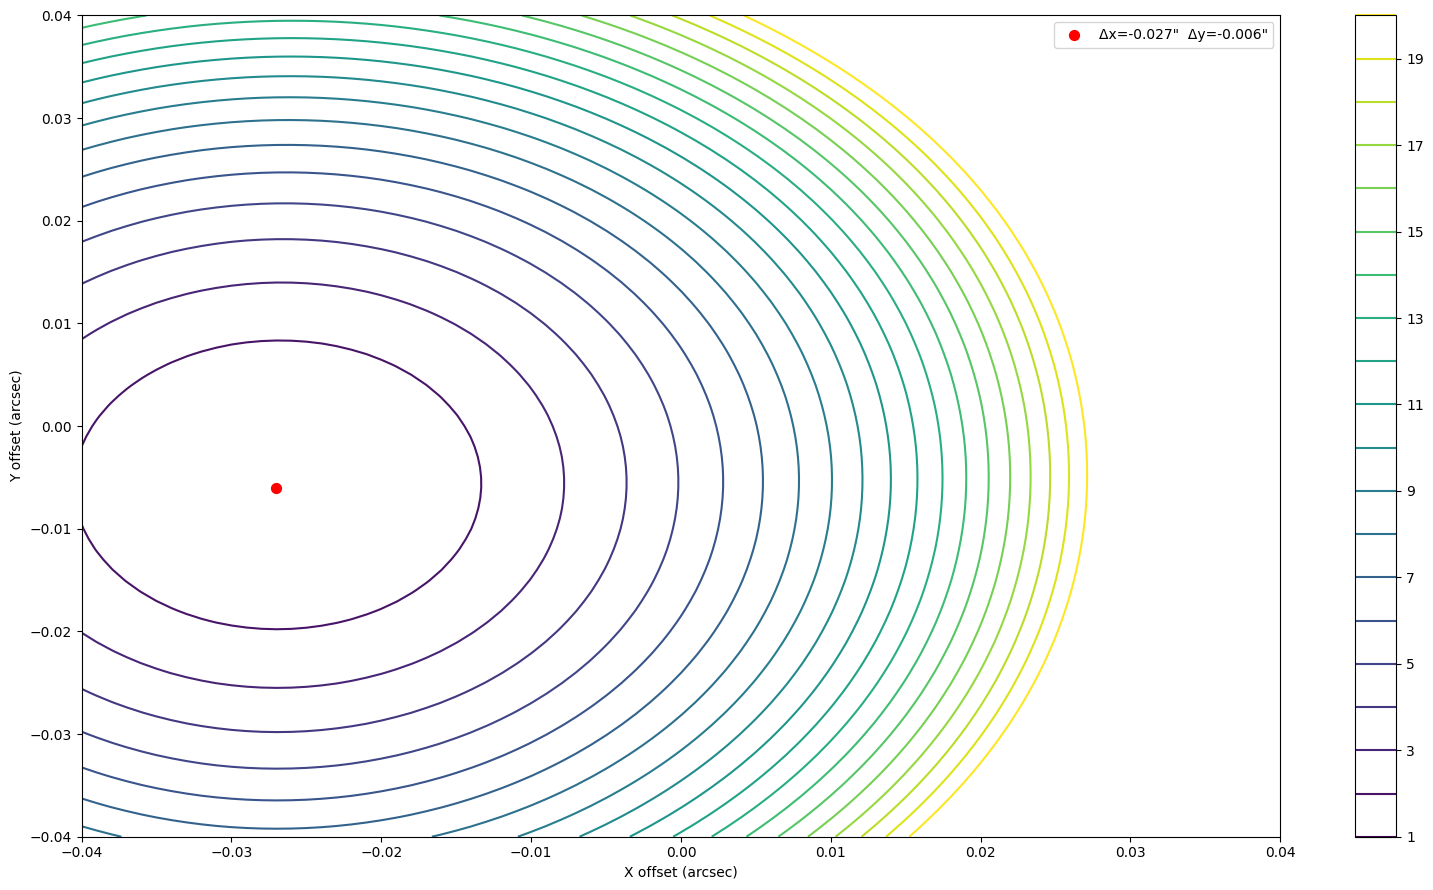

Best k: 1099
Best shift X: -0.027
Best shift Y: -0.006
fine_min_chi: 8.422061
1777.2707810630345 966.3011596364219


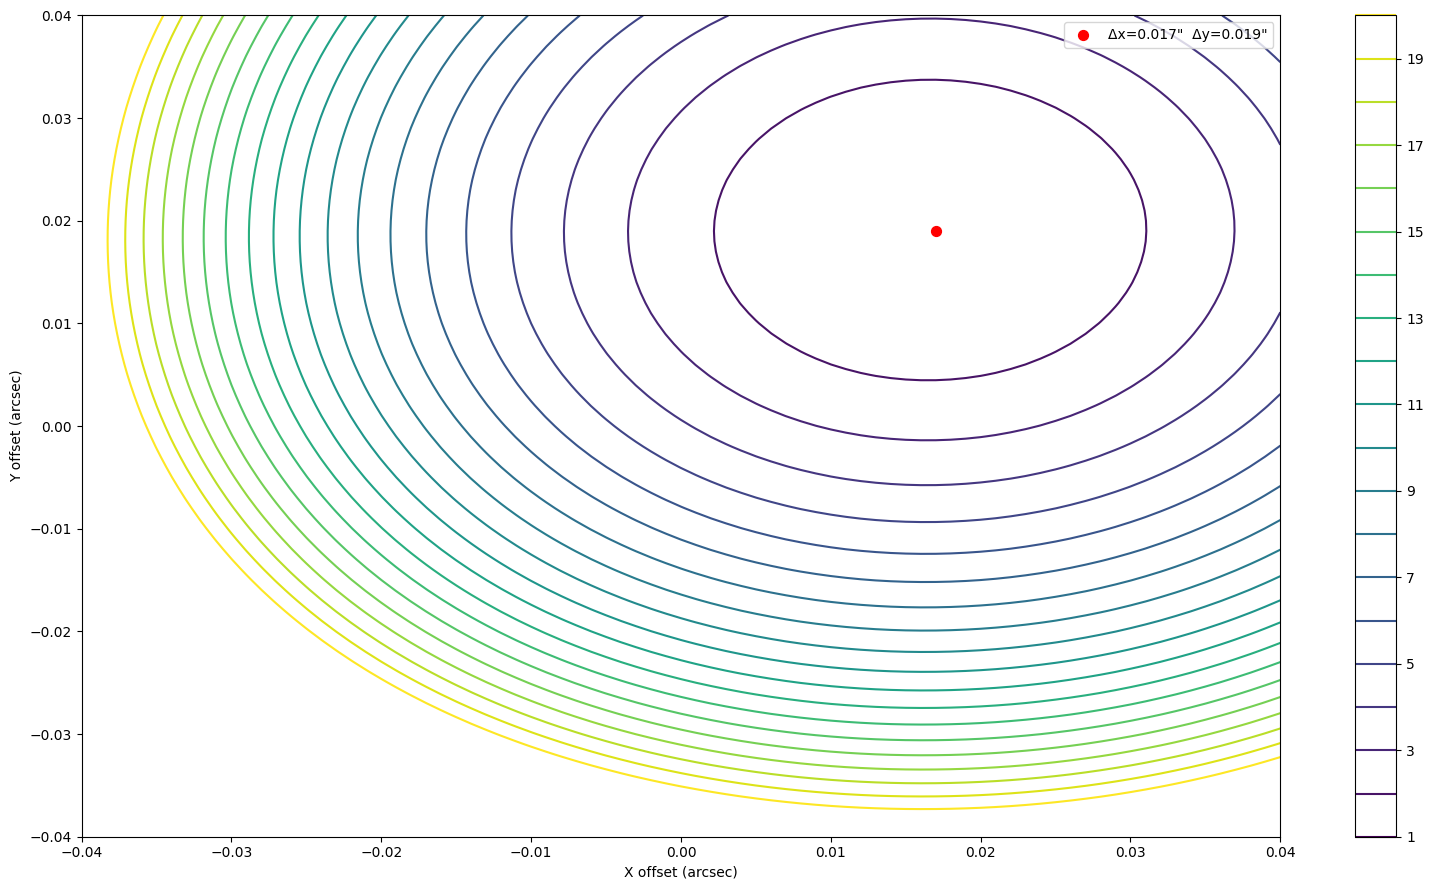

Best k: 4638
Best shift X: 0.017
Best shift Y: 0.019
fine_min_chi: 6.048215
1965.4937772325925 1054.7305413779384


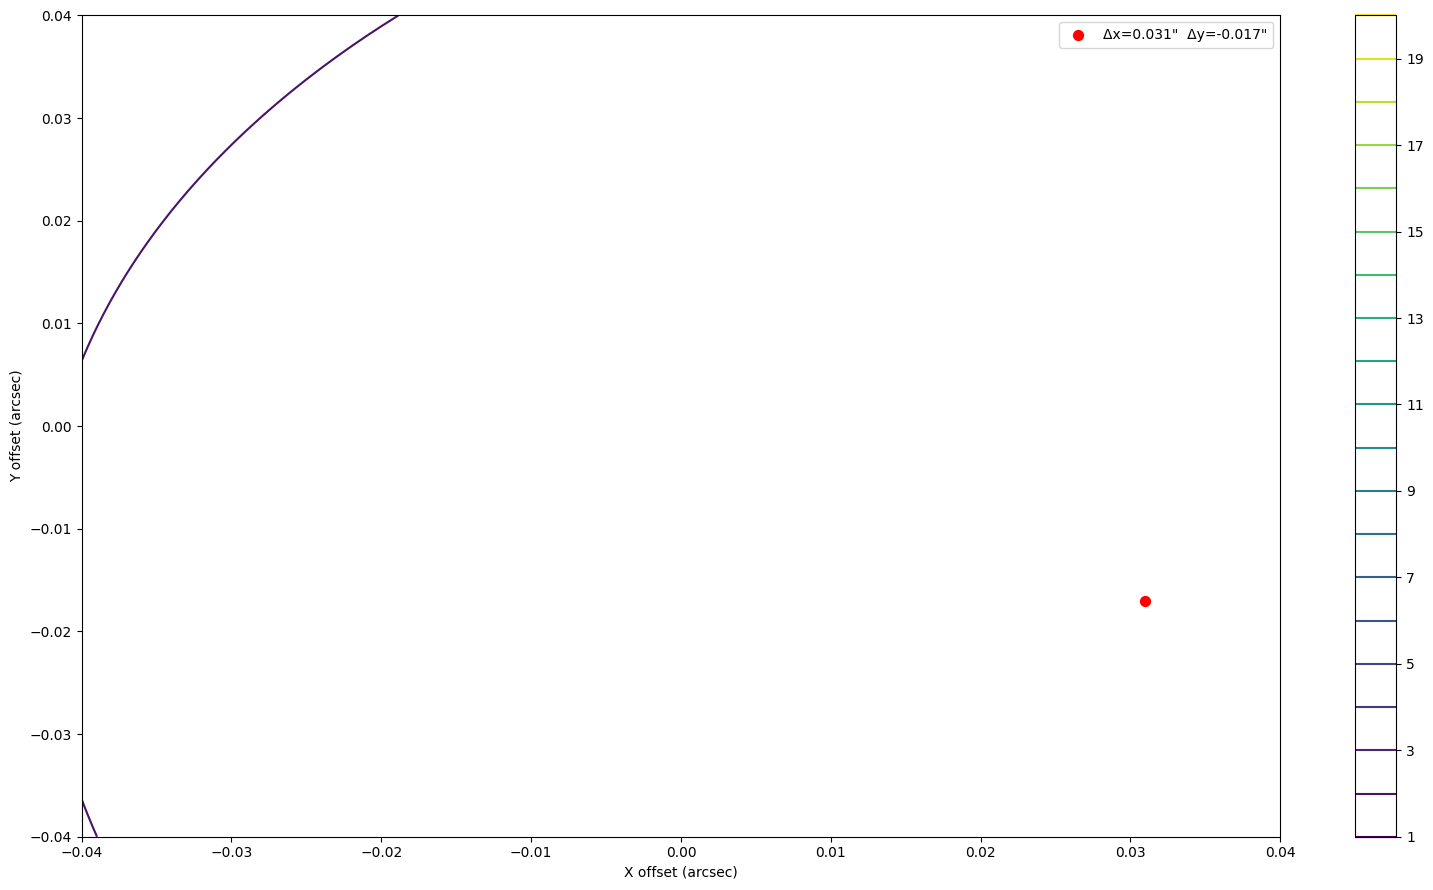

Best k: 5808
Best shift X: 0.031
Best shift Y: -0.017
fine_min_chi: 2.023087
2001.4743661717564 482.0158505071801


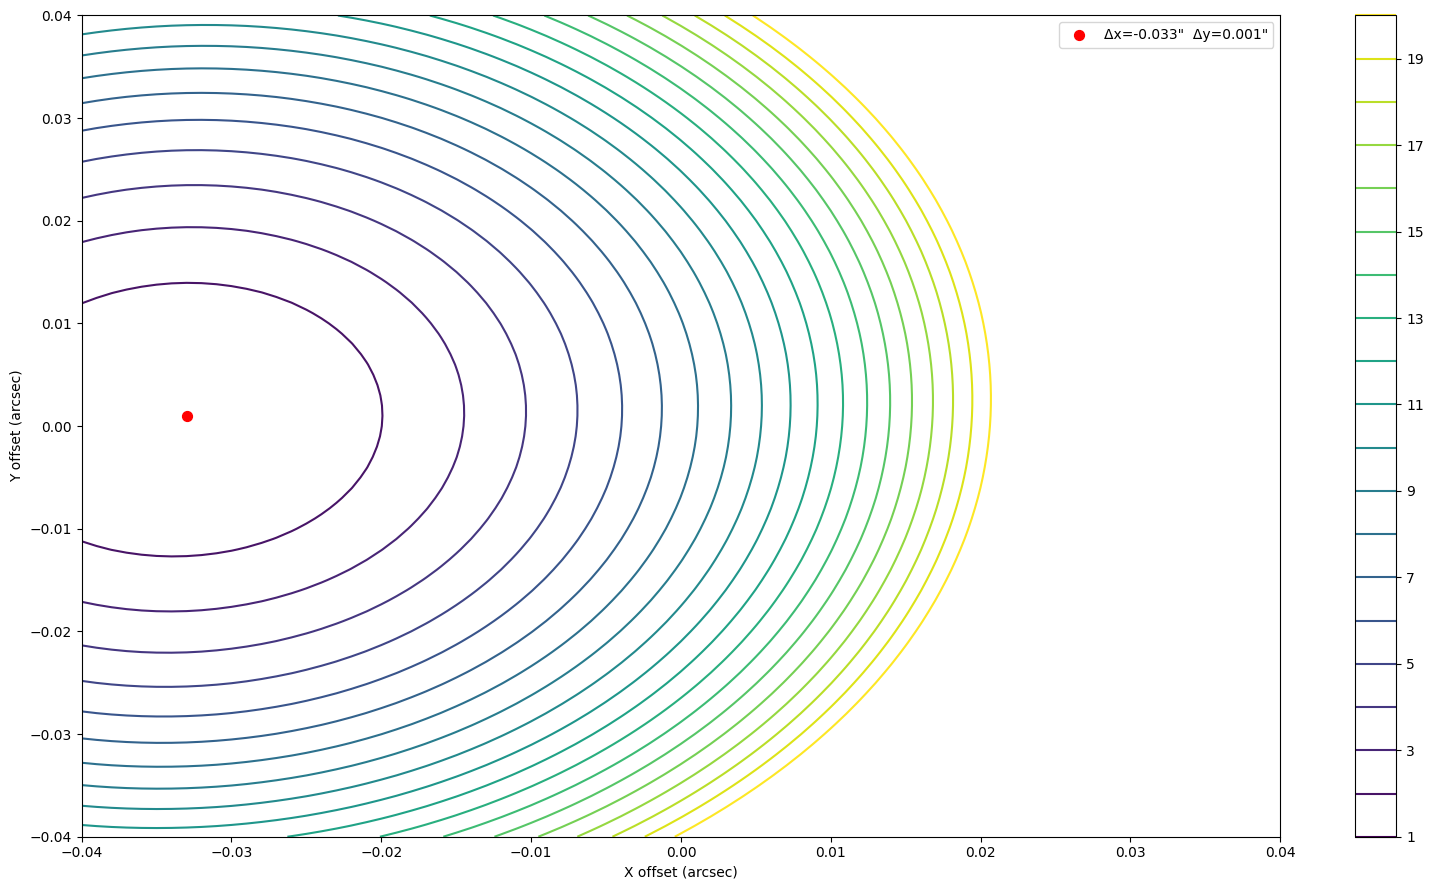

Best k: 606
Best shift X: -0.033
Best shift Y: 0.001
fine_min_chi: 4.156135


In [8]:
fine_best_x = []
fine_best_y = []
fine_min_chi = []
fine_x_shift = []
fine_y_shift = []
index = []

for k in range(len(best_x)):
    bestl_x, bestl_y, min_chil, x_shiftl, y_shiftl, lindex = psf_fitting(best_x[k], best_y[k], hdu_f_psf)
    fine_best_x.append(bestl_x)
    fine_best_y.append(bestl_y)
    fine_min_chi.append(min_chil)
    fine_x_shift.append(x_shiftl)
    fine_y_shift.append(y_shiftl)
    index.append(lindex)

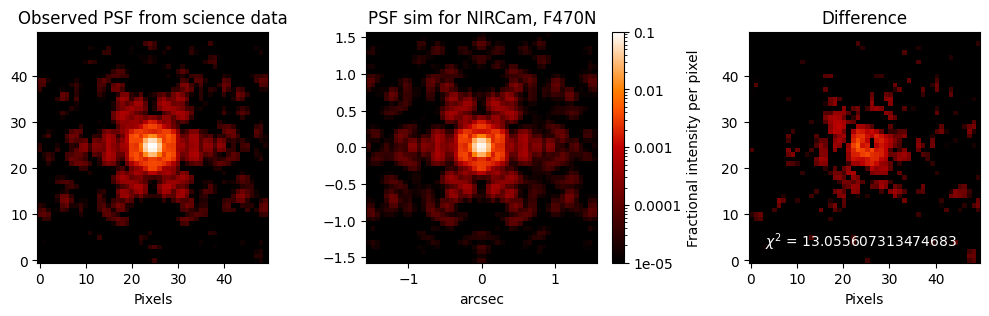

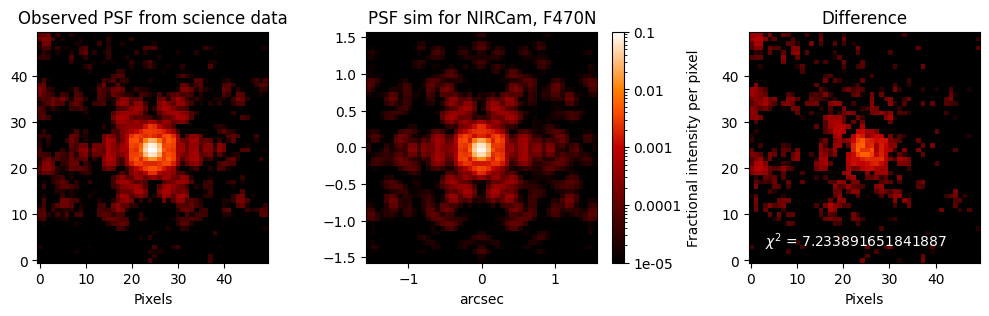

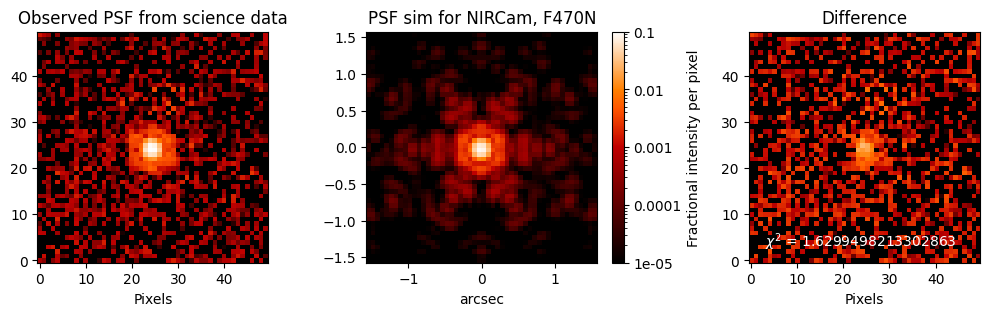

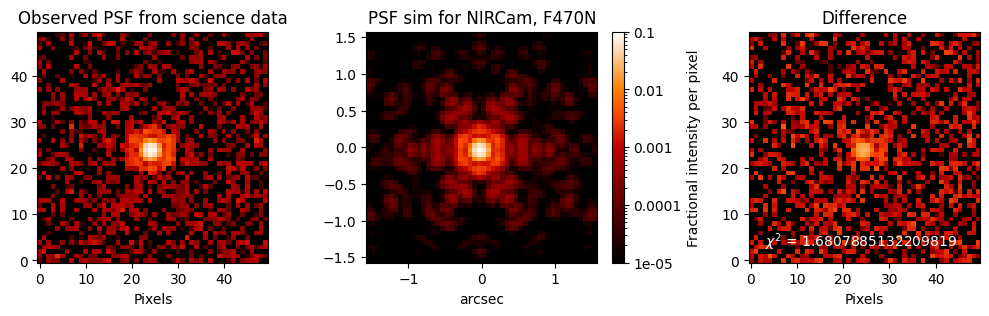

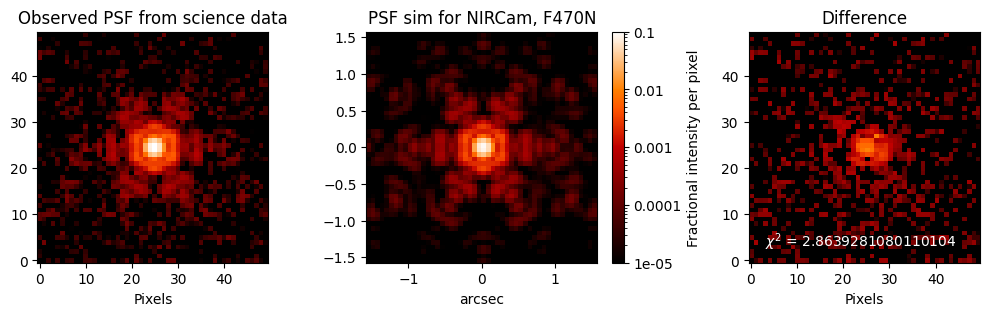

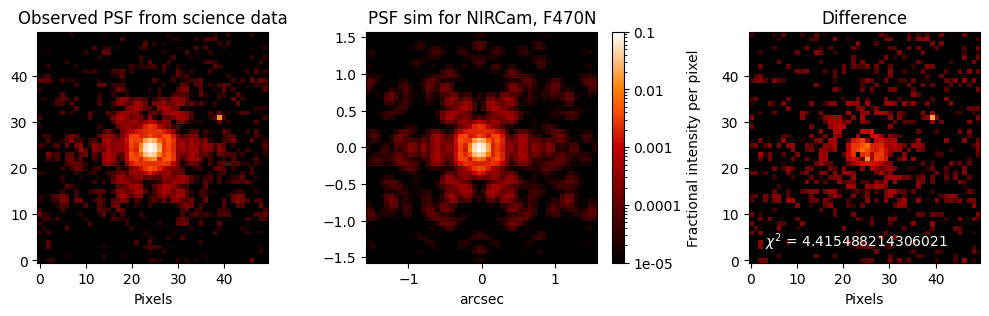

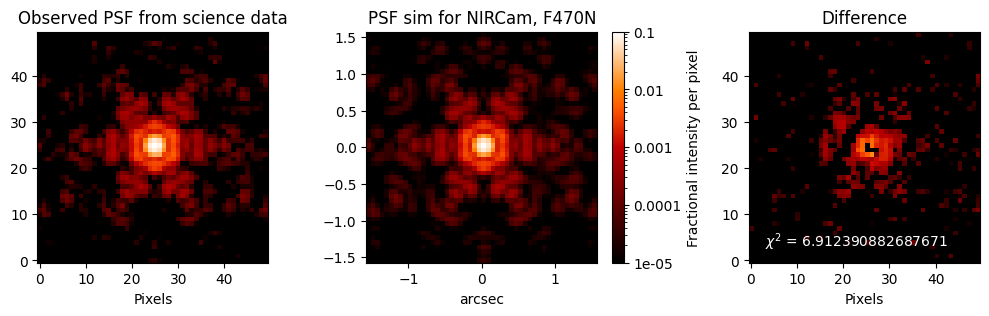

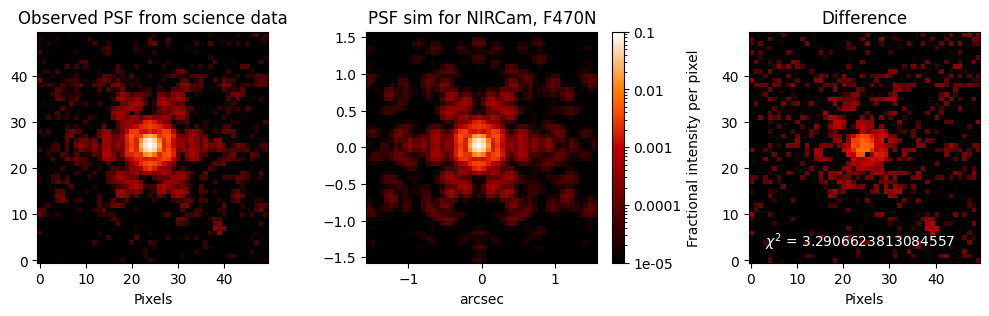

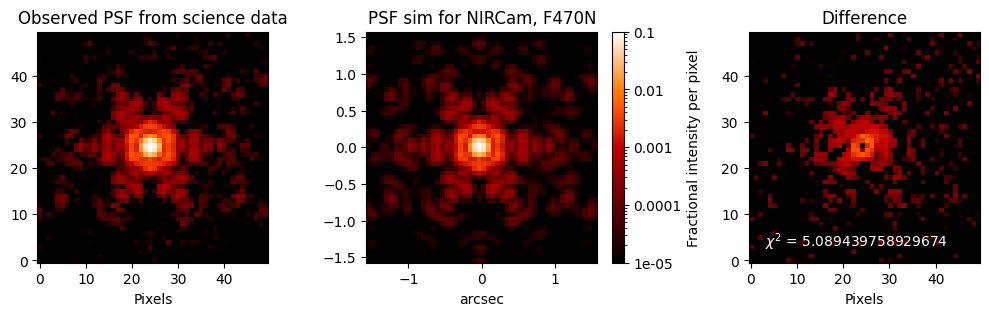

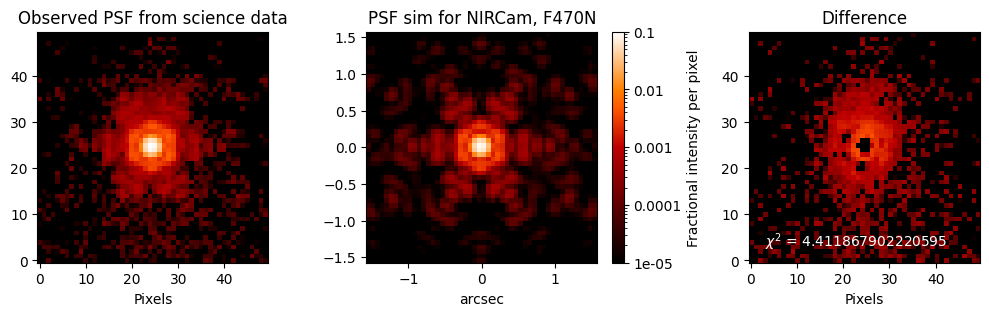

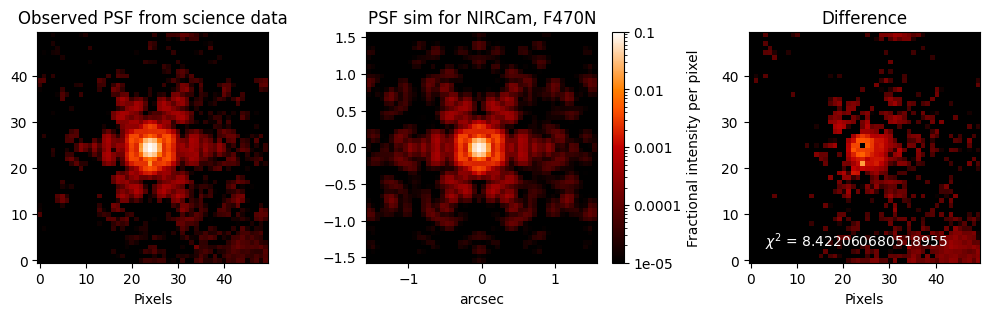

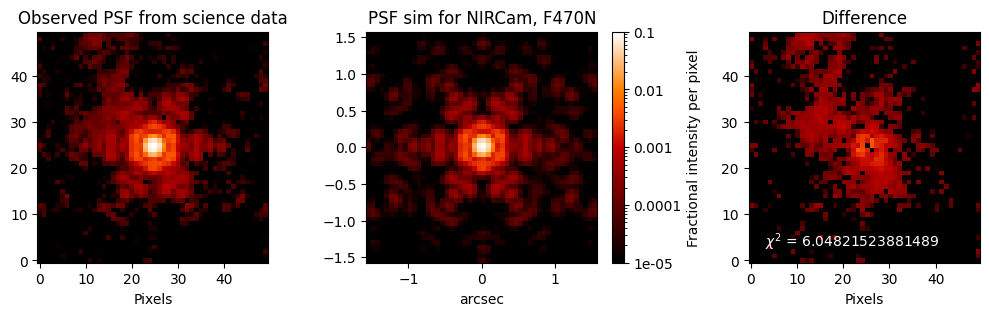

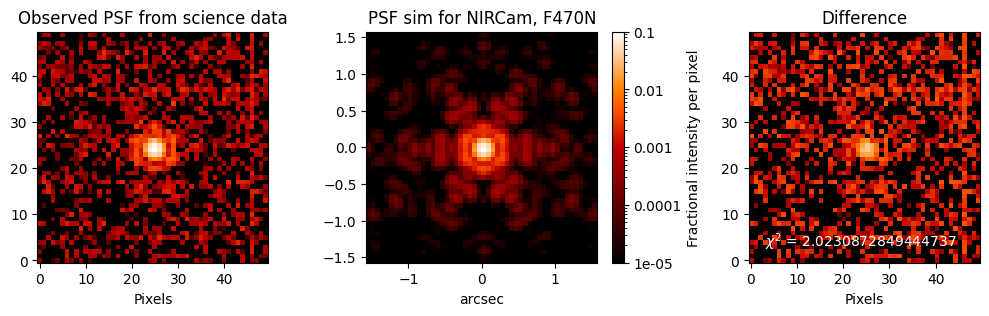

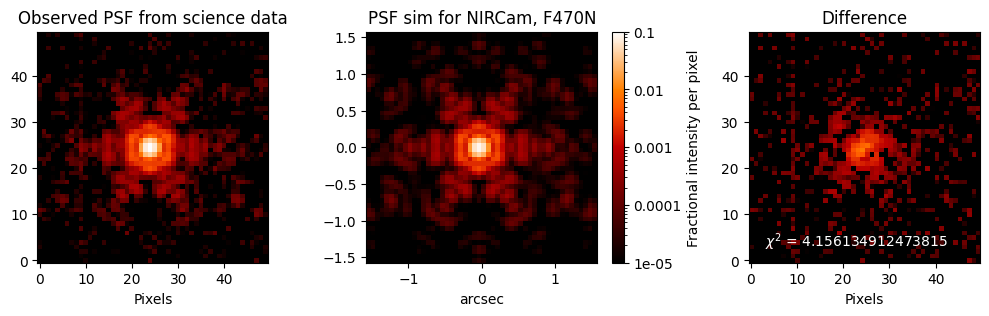

In [9]:
validation_chi = []
for k in range(len(best_x)):
    rounded_x = np.round(best_x[k])
    rounded_y = np.round(best_y[k])

    x_offset_pix = fine_best_x[k] - rounded_x
    y_offset_pix = fine_best_y[k] - rounded_y

    x_axis_scale = np.sqrt(header['CD1_1'] **2 + header['CD2_1'] **2 ) * 3600
    y_axis_scale = np.sqrt(header['CD1_2'] **2 + header['CD2_2'] **2 ) * 3600

    x_offset_arc = x_offset_pix * x_axis_scale
    y_offset_arc = y_offset_pix * y_axis_scale.copy()

    psf_center = (rounded_x, rounded_y)

    boxsize = 50
    inst = stpsf.setup_sim_to_match_file(fits_file, verbose= False)

    # Load that science data. Cut out the surface brightness and uncertainty for the desired location
    obs_im = fits.open(fits_file)

    obs_psf = Cutout2D(hdul['SCI'].data, position=psf_center, size=boxsize, mode='partial', fill_value=np.nan).data.copy()
    obs_psf_err = Cutout2D(hdul['ERR'].data, position=psf_center, size=boxsize, mode='partial', fill_value=np.nan).data.copy()

    obs_psf -= np.nanmedian(obs_psf)    # perform a simple background subtraction) 

    valid   = np.isfinite(obs_psf) & np.isfinite(obs_psf_err) & (obs_psf_err > 0)
    n_valid = int(valid.sum())
    err_sq  = obs_psf_err[valid] ** 2    

    # print (fine_x_shift, fine_y_shift)

    inst.options['source_offset_x'] = fine_x_shift[k]   # in units of arcseconds. So, this is about 1/5 of a NRC LW pixel
    inst.options['source_offset_y'] = fine_y_shift[k]

    sim_psf = inst.calc_psf(fov_pixels=boxsize)
    
    scalefactor = np.nansum(obs_psf) / np.nansum(sim_psf['DET_DIST'].data)

    diff = (obs_psf - (sim_psf['DET_DIST'].data * scalefactor))[valid]
    chisqr = np.nansum(diff**2/err_sq)/np.isfinite(diff).sum()

    diff_display = obs_psf - (sim_psf['DET_DIST'].data * scalefactor)

    fig, axes = plt.subplots(figsize=(13,3), ncols=3)

    vmax = np.nanmax(obs_psf)
    cmap = matplotlib.cm.gist_heat
    cmap.set_bad(cmap(0))
    axes[0].imshow(obs_psf, norm = matplotlib.colors.LogNorm(vmax/1e4, vmax), cmap=cmap, origin='lower')
    axes[0].set_title("Observed PSF from science data")

    stpsf.display_psf(sim_psf, ext='DET_DIST', vmax=0.1, vmin=1e-5, ax=axes[1], )
    
    axes[2].imshow(diff_display, norm = matplotlib.colors.LogNorm(vmax/1e5, vmax), cmap=cmap, origin='lower')


    validation_chi.append(chisqr)

    axes[2].set_title("Difference")
    axes[2].text(3, 3, f"$\\chi^2$ = {chisqr}", color='white')
    for ax in [axes[0], axes[2]]:
        ax.set_xlabel("Pixels")


In [10]:
np.array(validation_chi) - np.array(fine_min_chi)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

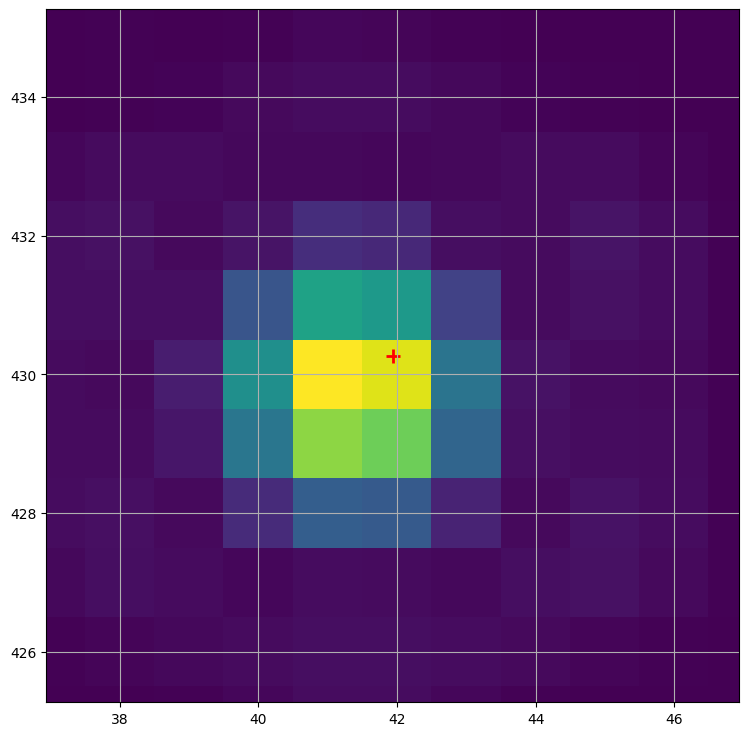

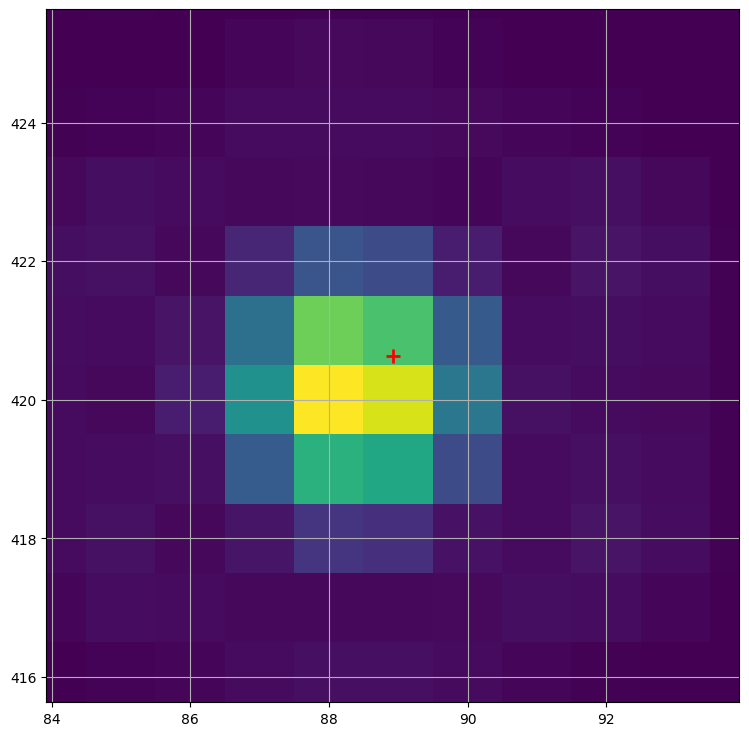

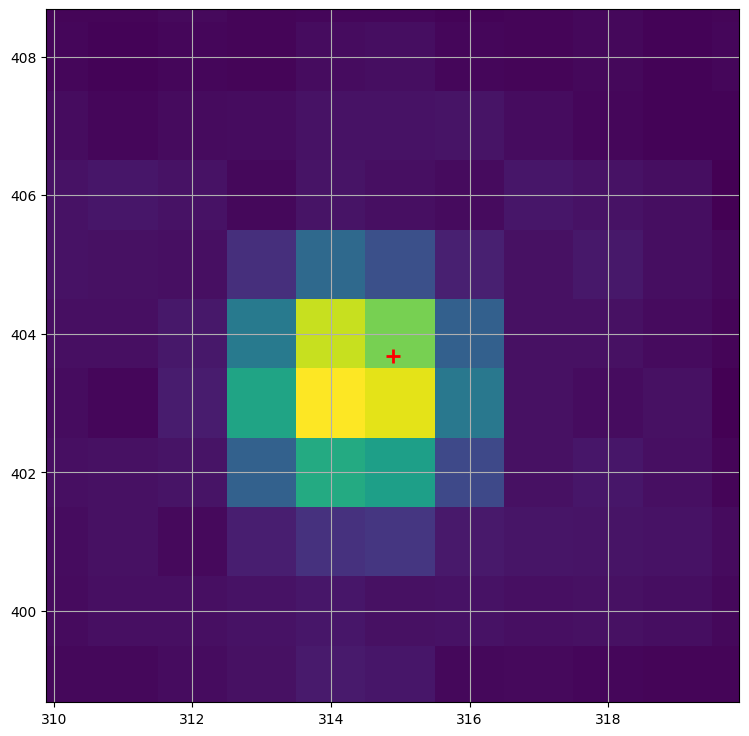

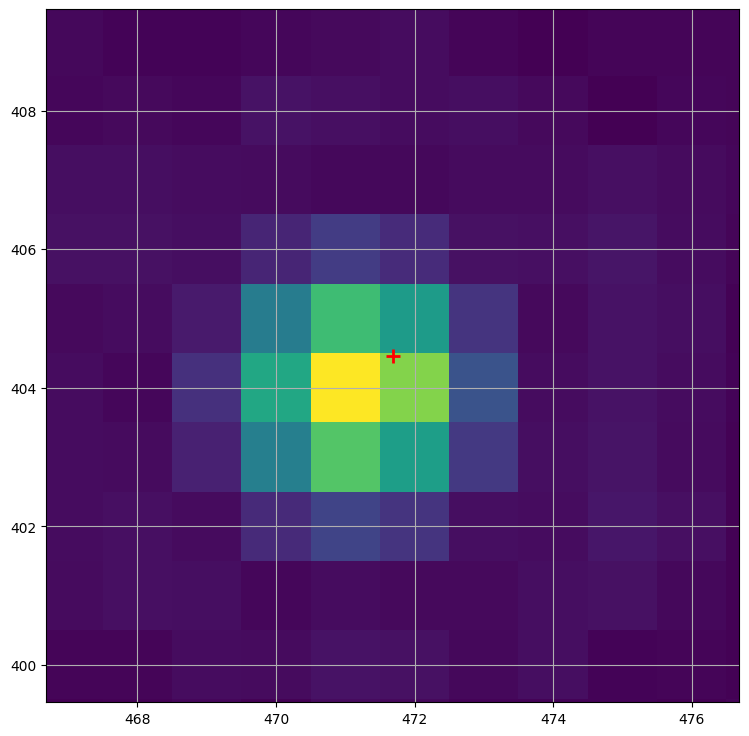

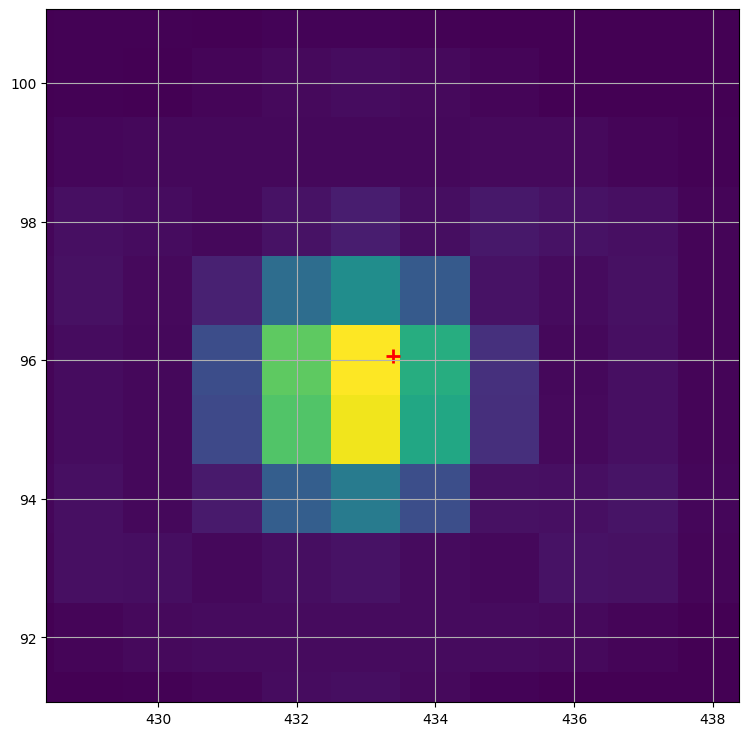

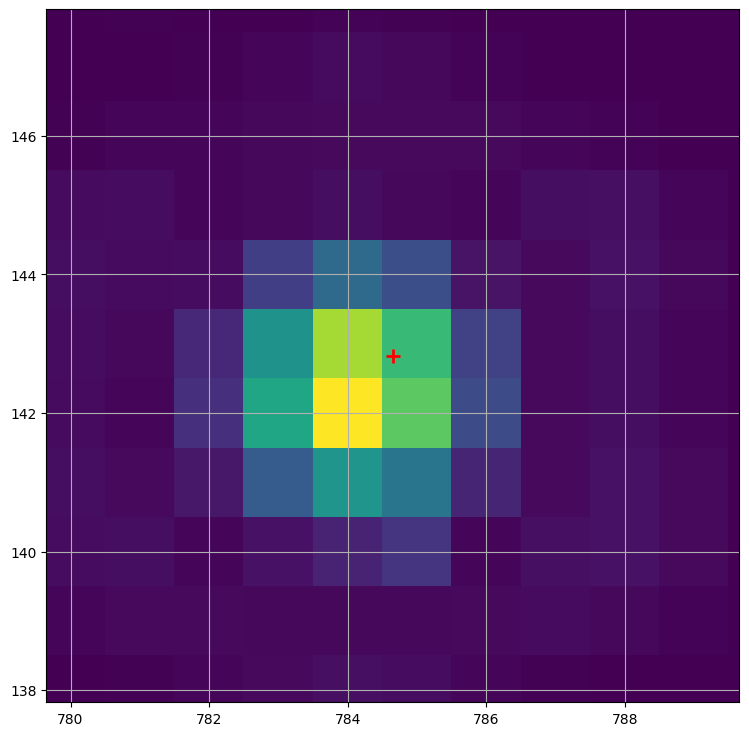

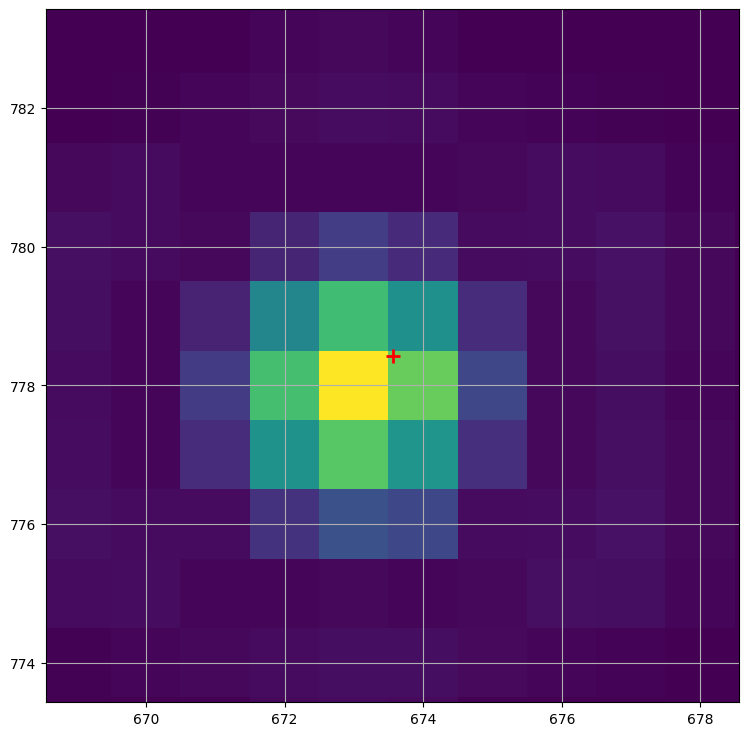

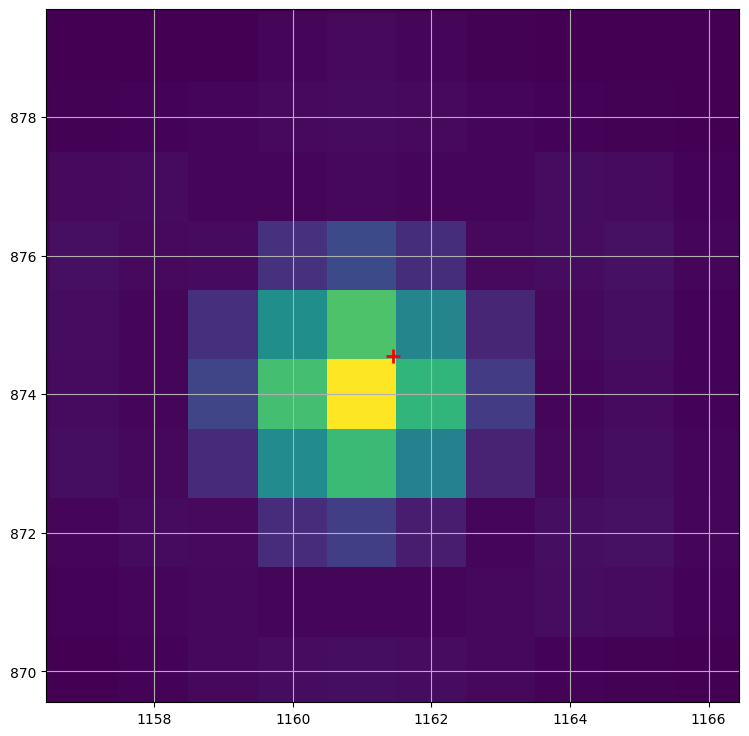

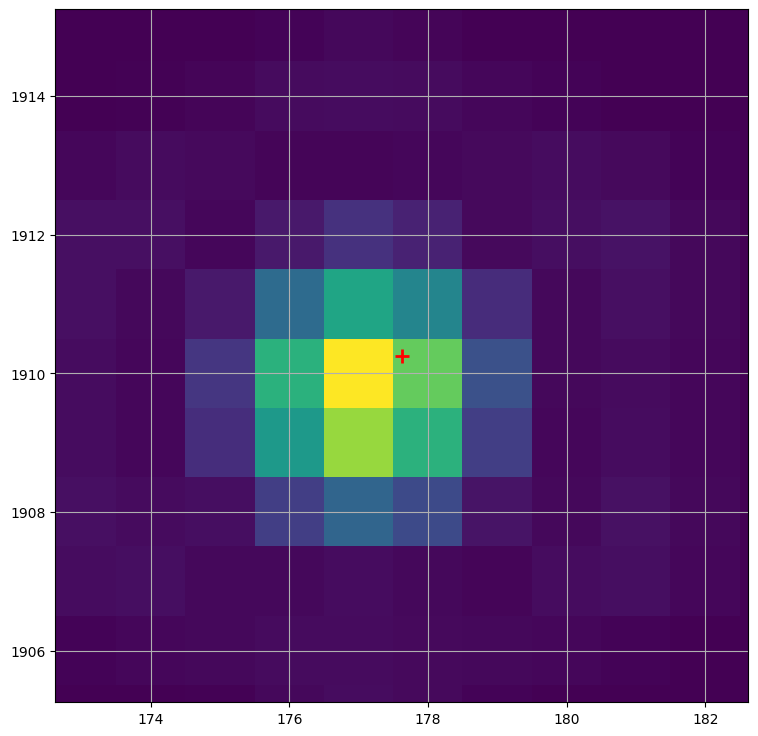

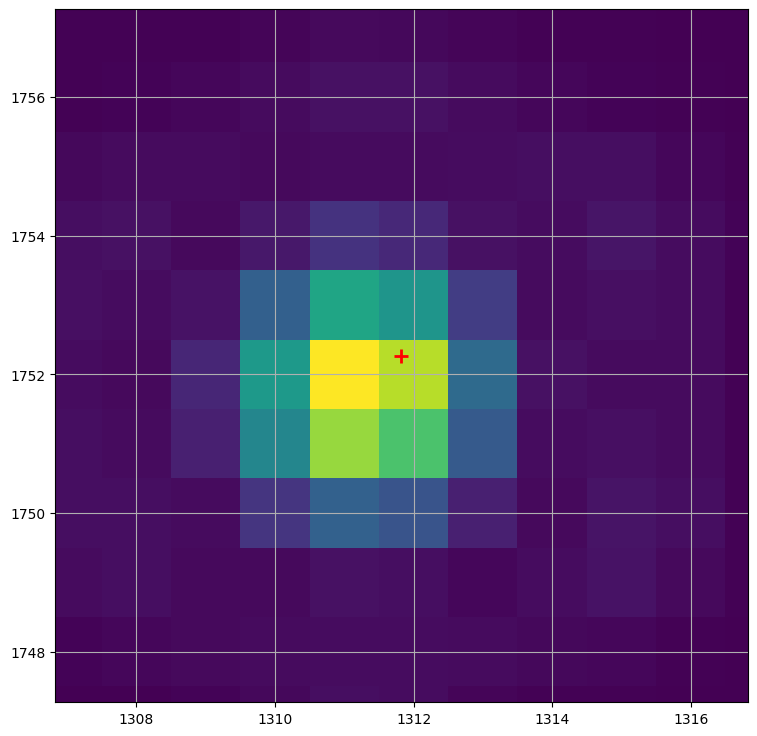

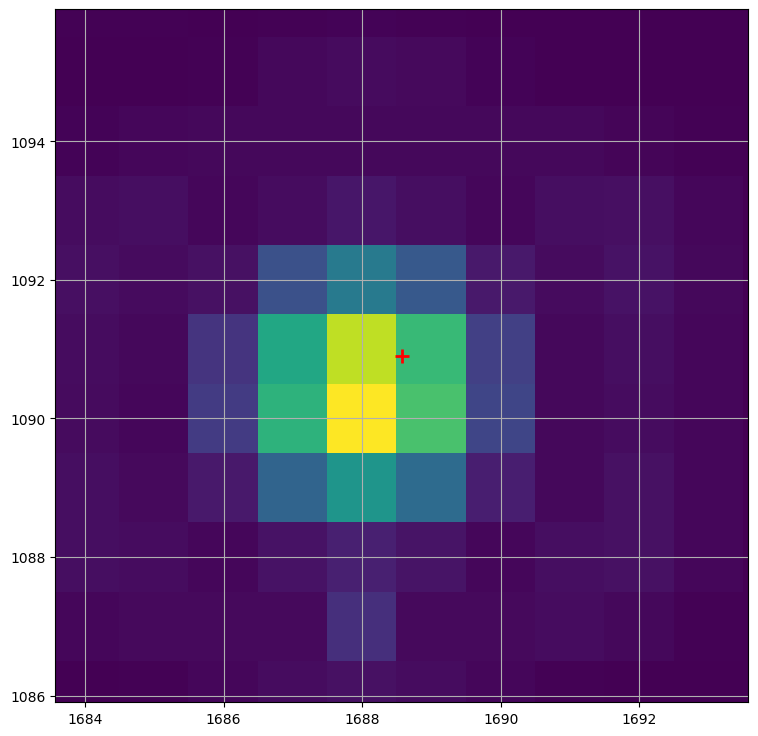

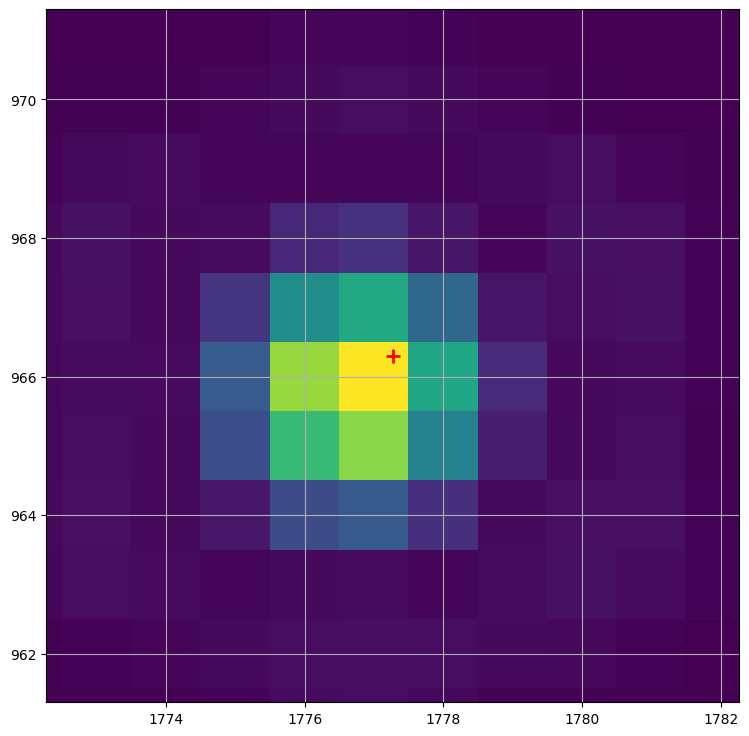

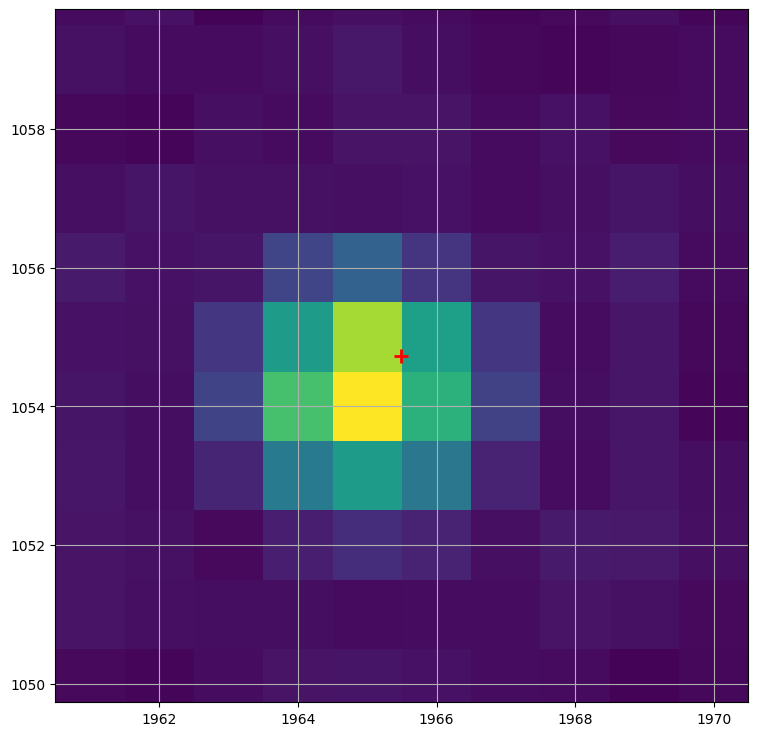

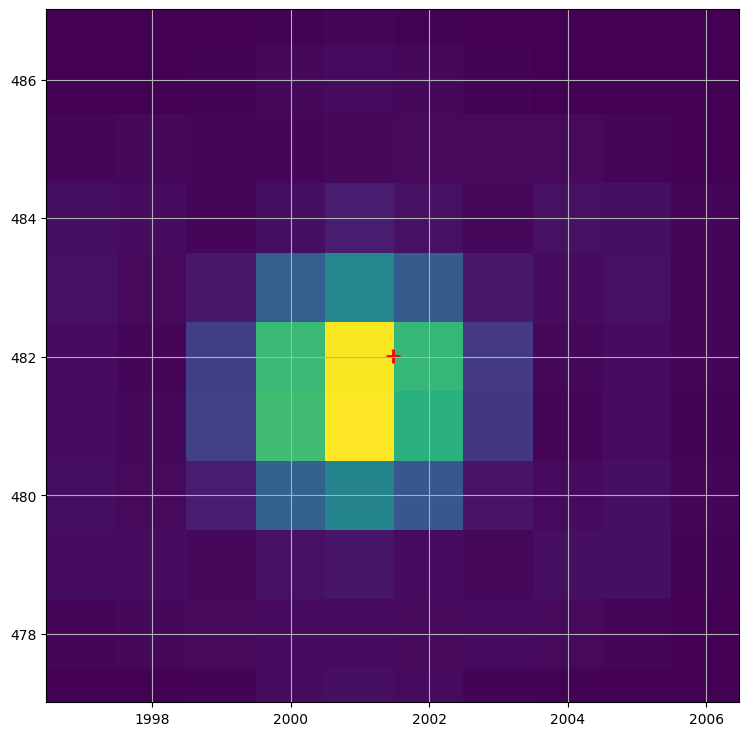

In [ ]:
size = 5
n = np.zeros(1)
for k in range(len(fine_best_x)):

    x0 = int(fine_best_x[k] - size)
    x1 = int(fine_best_x[k] + size)
    y0 = int(fine_best_y[k] - size)
    y1 = int(fine_best_y[k] + size)

    subarray = image[y0:y1, x0:x1]

    fig, ax = plt.subplots(1, 1,figsize=(9, 9))
    ax.imshow(image, origin='lower', vmin=np.min(subarray), vmax=np.max(subarray), cmap='viridis', interpolation='none')
    plt.grid(visible=None, which='major', axis='both')


    # x_pm, y_pm = apply_proper_motion_correction(header, gaia_star[index])

    ax.set_xlim([fine_best_x[k] - size, fine_best_x[k] + size])
    ax.set_ylim([fine_best_y[k] - size, fine_best_y[k] + size])


    ax.scatter(fine_best_x[k], fine_best_y[k], color='red', marker='+', s=100, linewidths=2)

    plt.rc('font', size=10)
    plt.show()